In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
# import colorcet as cc
import copy, os
import colormaps as cmaps
import easygems.healpix as egh

In [2]:
rootdir = '/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/'
name_map = {
    'obs': 'IMERGv7',
    'm1': 'scream',
    'm2': 'icon_d3hp003',
    'm3': 'nicam_gl11',
    'm4': 'um_glm_n2560_RAL3p3',
    'm5': 'casesm2_10km_nocumulus',
}
name_map_plot = {
    'obs': 'OBS',
    'm1': 'SCREAM',
    'm2': 'ICON',
    'm3': 'NICAM',
    'm4': 'UM',
    'm5': 'CASESM2',
}

# Input filenames
filenames = {key:f'{rootdir}{value}_monthly_rainmap_cof_hp8_v1.nc' for key,value in name_map.items()}

landmaskfile = '/global/cfs/cdirs/m4581/gsharing/hackathon/scream-cess-healpix/scream2D_hrly_topo_hp8_v7.zarr'

figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/


### Check if input files exist

In [3]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/IMERGv7_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/scream_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/icon_d3hp003_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/nicam_gl11_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/um_glm_n2560_RAL3p3_monthly_rainmap_cof_hp8_v1.nc: True
/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/monthly/casesm2_10km_nocumulus_monthly_rainmap_cof_hp8_v1.nc: True


In [4]:
dstop = xr.open_dataset(landmaskfile)
ter = dstop.ELEV
landfrac = dstop.LANDFRAC
dstop

<xarray.Dataset> Size: 13MB
Dimensions:   (cell: 786432, crs: 0)
Coordinates:
  * crs       (crs) float64 0B 
Dimensions without coordinates: cell
Data variables:
    ELEV      (cell) float32 3MB ...
    LANDFRAC  (cell) float32 3MB ...
    lat       (cell) float32 3MB ...
    lon       (cell) float32 3MB ...
Attributes:
    NCO:                        netCDF Operators version 4.9.8-alpha01 (Homep...
    history:                    Fri Jun 11 12:26:48 2021: ncks -A USGS-gtopo3...
    history_of_appended_files:  Fri Jun 11 12:26:48 2021: Appended file USGS-...
    source:                     USGS 30-sec dataset binned to ncube3000 (cube...
    title:                      30-second USGS topo data

<Figure size 640x480 with 0 Axes>

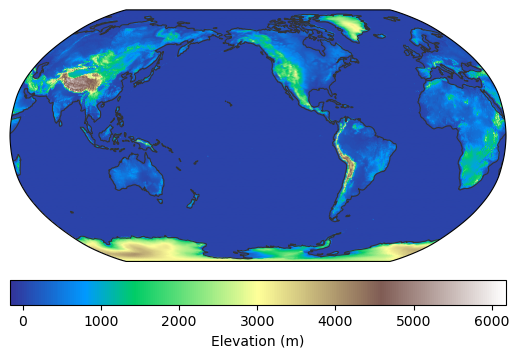

In [5]:
im = egh.healpix_show(ter, cmap='terrain')
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Elevation (m)')

<Figure size 640x480 with 0 Axes>

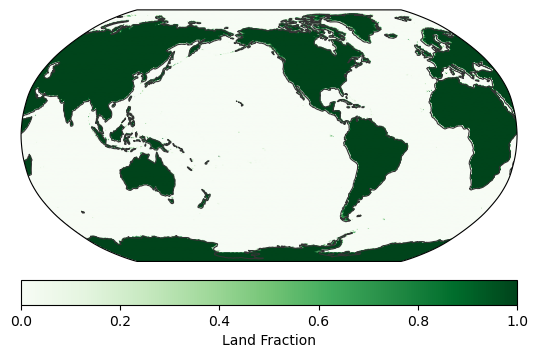

In [6]:
im = egh.healpix_show(landfrac, cmap='Greens', vmin=0, vmax=1)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Land Fraction')

## Read and combine all sources to a single DataSet

In [ ]:
drop_vars = []
# Read all files and combine them with a new dimension 'source'
ds = xr.open_mfdataset(list(filenames.values()), combine='nested', concat_dim='source', drop_variables=drop_vars).squeeze()
# Assign new coordinate 'source' using name_map dictionary keys
ds['source'] = list(name_map.keys())
# ds = ds.pipe(egh.attach_coords)
# Load lat/lon coordinates in memory
hp_lat = ds.lat.load()
hp_lon = ds.lon.load()
ds

<xarray.Dataset> Size: 16GB
Dimensions:                         (source: 6, time: 20, cell: 786432)
Coordinates:
  * time                            (time) datetime64[ns] 160B 2019-08-01 ......
  * cell                            (cell) int32 3MB 0 1 2 ... 786430 786431
    lat                             (cell) float64 6MB 0.1492 0.2984 ... -0.1492
    lon                             (cell) float64 6MB 45.0 45.18 ... 315.0
    crs                             int64 8B 0
  * source                          (source) <U3 72B 'obs' 'm1' ... 'm4' 'm5'
Data variables: (12/43)
    precipitation                   (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ntimes                          (source, time) float32 480B dask.array<chunksize=(1, 12), meta=np.ndarray>
    mcs_precipitation               (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_count                       (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    mcs_precipitation_count         (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ar_precipitation                (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    ...                              ...
    st_precipitation                (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    st_count                        (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    nd_precipitation                (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    nd_count                        (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    dz_precipitation                (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
    dz_count                        (source, time, cell) float32 377MB dask.array<chunksize=(1, 1, 786432), meta=np.ndarray>
Attributes:
    Title:                    Monthly precipitation statistics by co-occurren...
    contact:                  Zhe Feng, zhe.feng@pnnl.gov
    created_on:               Wed Oct 29 12:38:23 2025
    grid_type:                HEALPix
    zoom_level:               8
    time_interval:            6.0
    precipitation_threshold:  0.1

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [8]:
ds.ntimes.sum(dim='time').values

array([1588., 1576., 1460., 1459., 1576., 1459.], dtype=float32)

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages

### Feature precipitation amount & fraction by season

In [9]:
# Get time interval from attributes
time_interval = float(ds.attrs['time_interval'])

# Group by season and compute seasonal means
# Group dataset by season
ds_season = ds.groupby('time.season')

# Calculate total hours for each season
ntimes_season = ds_season.map(lambda x: x.ntimes.sum(dim='time'))
nhours_season = ntimes_season * time_interval

# Sum seasonal precipitation amount [mm], divided by total hours to get mm/day
tot_pcp_season = ds_season.map(lambda x: 24. * x.precipitation.sum(dim='time')).compute() / nhours_season

# Original features
mcs_pcp_season = ds_season.map(lambda x: 24. * x.mcs_precipitation.sum(dim='time')).compute() / nhours_season
ar_pcp_season = ds_season.map(lambda x: 24. * x.ar_precipitation.sum(dim='time')).compute() / nhours_season
etc_pcp_season = ds_season.map(lambda x: 24. * x.etc_precipitation.sum(dim='time')).compute() / nhours_season
tc_pcp_season = ds_season.map(lambda x: 24. * x.tc_precipitation.sum(dim='time')).compute() / nhours_season

# Isolated features only
mcs_iso_pcp_season = ds_season.map(lambda x: 24. * x.mcs_iso_precipitation.sum(dim='time')).compute() / nhours_season
ar_iso_pcp_season = ds_season.map(lambda x: 24. * x.ar_iso_precipitation.sum(dim='time')).compute() / nhours_season
etc_iso_pcp_season = ds_season.map(lambda x: 24. * x.etc_iso_precipitation.sum(dim='time')).compute() / nhours_season

# Co-occurrence features
mcs_ar_pcp_season = ds_season.map(lambda x: 24. * x.mcs_ar_precipitation.sum(dim='time')).compute() / nhours_season
mcs_etc_pcp_season = ds_season.map(lambda x: 24. * x.mcs_etc_precipitation.sum(dim='time')).compute() / nhours_season
ar_etc_pcp_season = ds_season.map(lambda x: 24. * x.ar_etc_precipitation.sum(dim='time')).compute() / nhours_season
mcs_ar_etc_pcp_season = ds_season.map(lambda x: 24. * x.mcs_ar_etc_precipitation.sum(dim='time')).compute() / nhours_season

# Cloud types (not tracked)
dc_pcp_season = ds_season.map(lambda x: 24. * x.dc_precipitation.sum(dim='time')).compute() / nhours_season
nd_pcp_season = ds_season.map(lambda x: 24. * x.nd_precipitation.sum(dim='time')).compute() / nhours_season
st_pcp_season = ds_season.map(lambda x: 24. * x.st_precipitation.sum(dim='time')).compute() / nhours_season
dz_pcp_season = ds_season.map(lambda x: 24. * x.dz_precipitation.sum(dim='time')).compute() / nhours_season

# Calculate precipitation fractions
# Original features
mcs_pcpfrac_season = 100. * mcs_pcp_season / tot_pcp_season
tc_pcpfrac_season = 100. * tc_pcp_season / tot_pcp_season

# Isolated features only
mcs_iso_pcpfrac_season = 100. * mcs_iso_pcp_season / tot_pcp_season
ar_iso_pcpfrac_season = 100. * ar_iso_pcp_season / tot_pcp_season
tc_pcpfrac_season = 100. * tc_pcp_season / tot_pcp_season
etc_iso_pcpfrac_season = 100. * etc_iso_pcp_season / tot_pcp_season

# Co-occurrence features
mcs_ar_pcpfrac_season = 100. * mcs_ar_pcp_season / tot_pcp_season
mcs_etc_pcpfrac_season = 100. * mcs_etc_pcp_season / tot_pcp_season
ar_etc_pcpfrac_season = 100. * ar_etc_pcp_season / tot_pcp_season
mcs_ar_etc_pcpfrac_season = 100. * mcs_ar_etc_pcp_season / tot_pcp_season

# Cloud types (not tracked)
dc_pcpfrac_season = 100. * dc_pcp_season / tot_pcp_season
nd_pcpfrac_season = 100. * nd_pcp_season / tot_pcp_season
st_pcpfrac_season = 100. * st_pcp_season / tot_pcp_season
dz_pcpfrac_season = 100. * dz_pcp_season / tot_pcp_season

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/dask/_task_spec.py:741: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages

<Figure size 640x480 with 0 Axes>

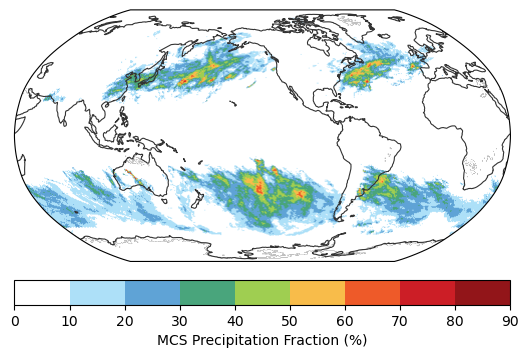

In [10]:
season = 'JJA'
# VAR = mcs_pcpfrac_season.sel(source='obs', season=season)
VAR = mcs_ar_pcpfrac_season.sel(source='obs', season=season)

colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 90.1, 10)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(VAR, cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='MCS Precipitation Fraction (%)')

### Feature frequency by season

In [11]:
# Calculate number of feature mask hours by season
# Original features
mcs_count_season = ds_season.map(lambda x: x.mcs_count.sum(dim='time')).compute()
ar_count_season = ds_season.map(lambda x: x.ar_count.sum(dim='time')).compute()
etc_count_season = ds_season.map(lambda x: x.etc_count.sum(dim='time')).compute()
tc_count_season = ds_season.map(lambda x: x.tc_count.sum(dim='time')).compute()

# Isolated features only
mcs_iso_count_season = ds_season.map(lambda x: x.mcs_iso_count.sum(dim='time')).compute()
ar_iso_count_season = ds_season.map(lambda x: x.ar_iso_count.sum(dim='time')).compute()
etc_iso_count_season = ds_season.map(lambda x: x.etc_iso_count.sum(dim='time')).compute()

# Co-occurrence features
mcs_ar_count_season = ds_season.map(lambda x: x.mcs_ar_count.sum(dim='time')).compute()
mcs_etc_count_season = ds_season.map(lambda x: x.mcs_etc_count.sum(dim='time')).compute()
ar_etc_count_season = ds_season.map(lambda x: x.ar_etc_count.sum(dim='time')).compute()
mcs_ar_etc_count_season = ds_season.map(lambda x: x.mcs_ar_etc_count.sum(dim='time')).compute()

# Cloud types (not tracked)
dc_count_season = ds_season.map(lambda x: x.dc_count.sum(dim='time')).compute()
nd_count_season = ds_season.map(lambda x: x.nd_count.sum(dim='time')).compute()
st_count_season = ds_season.map(lambda x: x.st_count.sum(dim='time')).compute()
dz_count_season = ds_season.map(lambda x: x.dz_count.sum(dim='time')).compute()

# Calculate feature mask frequencies (as percentages)
# Original features
mcs_freq_season = 100. * mcs_count_season / nhours_season
ar_freq_season = 100. * ar_count_season / nhours_season
etc_freq_season = 100. * etc_count_season / nhours_season
tc_freq_season = 100. * tc_count_season / nhours_season

# Isolated features only
mcs_iso_freq_season = 100. * mcs_iso_count_season / nhours_season
ar_iso_freq_season = 100. * ar_iso_count_season / nhours_season
etc_iso_freq_season = 100. * etc_iso_count_season / nhours_season

# Co-occurrence features
mcs_ar_freq_season = 100. * mcs_ar_count_season / nhours_season
mcs_etc_freq_season = 100. * mcs_etc_count_season / nhours_season
ar_etc_freq_season = 100. * ar_etc_count_season / nhours_season
mcs_ar_etc_freq_season = 100. * mcs_ar_etc_count_season / nhours_season

# Cloud types (not tracked)
dc_freq_season = 100. * dc_count_season / nhours_season
nd_freq_season = 100. * nd_count_season / nhours_season
st_freq_season = 100. * st_count_season / nhours_season
dz_freq_season = 100. * dz_count_season / nhours_season

### Feature precipitation frequency by season

In [12]:
# Number of feature precipitation hours by season
# Original features
mcs_pcpcount_season = ds_season.map(lambda x: x.mcs_precipitation_count.sum(dim='time')).compute()
ar_pcpcount_season = ds_season.map(lambda x: x.ar_precipitation_count.sum(dim='time')).compute()
etc_pcpcount_season = ds_season.map(lambda x: x.etc_precipitation_count.sum(dim='time')).compute()
tc_pcpcount_season = ds_season.map(lambda x: x.tc_precipitation_count.sum(dim='time')).compute()

# Isolated features only
mcs_iso_pcpcount_season = ds_season.map(lambda x: x.mcs_iso_precipitation_count.sum(dim='time')).compute()
ar_iso_pcpcount_season = ds_season.map(lambda x: x.ar_iso_precipitation_count.sum(dim='time')).compute()
etc_iso_pcpcount_season = ds_season.map(lambda x: x.etc_iso_precipitation_count.sum(dim='time')).compute()

# Co-occurrence features
mcs_ar_pcpcount_season = ds_season.map(lambda x: x.mcs_ar_precipitation_count.sum(dim='time')).compute()
mcs_etc_pcpcount_season = ds_season.map(lambda x: x.mcs_etc_precipitation_count.sum(dim='time')).compute()
ar_etc_pcpcount_season = ds_season.map(lambda x: x.ar_etc_precipitation_count.sum(dim='time')).compute()
mcs_ar_etc_pcpcount_season = ds_season.map(lambda x: x.mcs_ar_etc_precipitation_count.sum(dim='time')).compute()

# Calculate feature precipitation frequencies (as percentages)
# Original features
mcs_pcpfreq_season = 100 * mcs_pcpcount_season / ntimes_season
ar_pcpfreq_season = 100 * ar_pcpcount_season / ntimes_season
etc_pcpfreq_season = 100 * etc_pcpcount_season / ntimes_season
tc_pcpfreq_season = 100 * tc_pcpcount_season / ntimes_season

# Isolated features only
mcs_iso_pcpfreq_season = 100 * mcs_iso_pcpcount_season / ntimes_season
ar_iso_pcpfreq_season = 100 * ar_iso_pcpcount_season / ntimes_season
etc_iso_pcpfreq_season = 100 * etc_iso_pcpcount_season / ntimes_season

# Co-occurrence features
mcs_ar_pcpfreq_season = 100 * mcs_ar_pcpcount_season / ntimes_season
mcs_etc_pcpfreq_season = 100 * mcs_etc_pcpcount_season / ntimes_season
ar_etc_pcpfreq_season = 100 * ar_etc_pcpcount_season / ntimes_season
mcs_ar_etc_pcpfreq_season = 100 * mcs_ar_etc_pcpcount_season / ntimes_season

<Figure size 640x480 with 0 Axes>

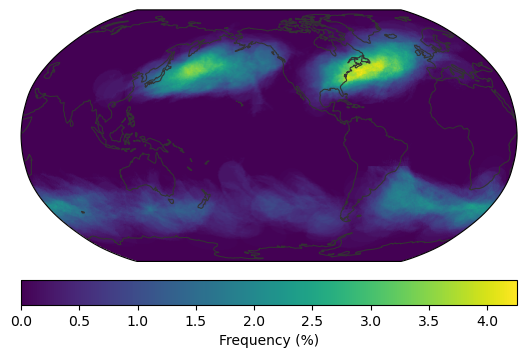

In [13]:
season = 'DJF'
# VAR = mcs_freq_season.sel(source='obs', season=season)
# VAR = etc_iso_freq_season.sel(source='obs', season=season)
# VAR = ar_iso_freq_season.sel(source='obs', season=season)
# VAR = mcs_ar_freq_season.sel(source='obs', season=season)
VAR = mcs_ar_etc_freq_season.sel(source='obs', season=season)

im = egh.healpix_show(VAR)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Frequency (%)')

### Precipitation amount and fraction by season (land vs. ocean)

<Figure size 640x480 with 0 Axes>

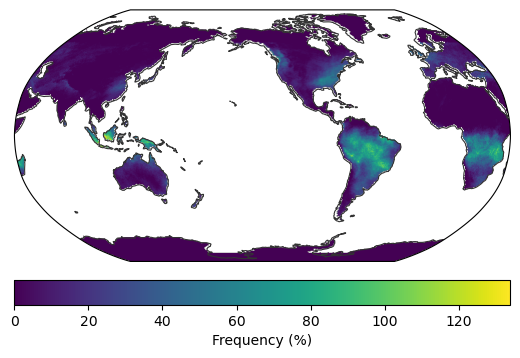

In [14]:
season = 'DJF'
VAR = mcs_pcpcount_season.where(landfrac == 1).sel(season='DJF', source='obs')

im = egh.healpix_show(VAR)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Frequency (%)')

### Function to compute zonal mean

In [15]:
def compute_seasonal_zonal_mean(var_season, lat_var, lat_bins=None):
    """
    Compute zonal means for a seasonal variable using xarray's groupby_bins.
    
    This implementation is much faster than looping as it leverages xarray's
    vectorized operations and efficient groupby mechanism.
    
    Parameters
    ----------
    var_season : xarray.DataArray
        Seasonal variable with dimensions (season, cell) or (season, source, cell)
        where cell corresponds to HEALPix cells. The 'lat' coordinate should be
        associated with the 'cell' dimension.
    lat_var : xarray.DataArray
        Latitude values for each cell (1D array with dimension 'cell').
        Not used directly but kept for API compatibility.
    lat_bins : array-like, optional
        Latitude bin edges for grouping. If None, uses 1-degree bins from -90 to 90.
        
    Returns
    -------
    xarray.DataArray
        Zonal mean values with dimensions (season, latitude) if no source dimension,
        or (season, source, latitude) if source dimension exists
        
    Example
    -------
    >>> mcs_zonal = compute_seasonal_zonal_mean(mcs_pcp_season, ds.lat)
    >>> # Result shape: (season: 4, source: 6, latitude: 180) for 1-degree bins with sources
    >>> # or (season: 4, latitude: 180) for 1-degree bins without sources
    """
    
    # Default latitude bins: 1-degree resolution
    if lat_bins is None:
        lat_bins = np.arange(-90, 91, 1)
    
    # Get latitude centers from bin edges
    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    
    # Use groupby_bins to efficiently group by latitude and compute means
    # Don't use labels parameter - we'll assign numeric coordinates afterward
    zonal_grouped = var_season.groupby_bins('lat', bins=lat_bins)
    
    # Compute the mean across cells in each latitude bin
    # This automatically preserves other dimensions (season, source if present)
    result = zonal_grouped.mean(dim='cell')
    
    # Rename the grouped dimension to 'latitude'
    result = result.rename({'lat_bins': 'latitude'})
    
    # Replace the interval index with numeric latitude centers
    # This makes it possible to use .sel(latitude=10, method='nearest')
    result = result.assign_coords(latitude=lat_centers)
    
    # Update attributes
    result.attrs['long_name'] = f'Zonal mean of {var_season.name if hasattr(var_season, "name") else "variable"}'
    if hasattr(var_season, 'attrs') and 'units' in var_season.attrs:
        result.attrs['units'] = var_season.attrs['units']
    
    return result

In [16]:
# # Demonstration: Compute zonal means for MCS precipitation
# # Using 2-degree latitude bins for faster computation
# lat_bins = np.arange(-60, 61, 1)

# # Compute zonal mean for MCS precipitation (handles multiple sources automatically)
# mcs_pcp_zonal = compute_seasonal_zonal_mean(mcs_pcp_season, ds.lat, lat_bins=lat_bins)

# print(f"Zonal mean shape: {mcs_pcp_zonal.shape}")
# print(f"Dimensions: {mcs_pcp_zonal.dims}")
# print(f"Seasons: {mcs_pcp_zonal.season.values}")
# if 'source' in mcs_pcp_zonal.dims:
#     print(f"Sources: {mcs_pcp_zonal.source.values}")
# print(f"Latitude range: {mcs_pcp_zonal.latitude.min().values:.1f} to {mcs_pcp_zonal.latitude.max().values:.1f}")

In [17]:
# Compute zonal means for all feature types and metrics
# Using 2-degree latitude bins for efficiency
lat_bins = np.arange(-60, 61, 2)

print("Computing zonal means for precipitation amounts...")
# Total precipitation
tot_pcp_zonal = compute_seasonal_zonal_mean(tot_pcp_season, ds.lat, lat_bins=lat_bins)

# Original features
mcs_pcp_zonal = compute_seasonal_zonal_mean(mcs_pcp_season, ds.lat, lat_bins=lat_bins)
ar_pcp_zonal = compute_seasonal_zonal_mean(ar_pcp_season, ds.lat, lat_bins=lat_bins)
etc_pcp_zonal = compute_seasonal_zonal_mean(etc_pcp_season, ds.lat, lat_bins=lat_bins)
tc_pcp_zonal = compute_seasonal_zonal_mean(tc_pcp_season, ds.lat, lat_bins=lat_bins)

# Isolated features
mcs_iso_pcp_zonal = compute_seasonal_zonal_mean(mcs_iso_pcp_season, ds.lat, lat_bins=lat_bins)
ar_iso_pcp_zonal = compute_seasonal_zonal_mean(ar_iso_pcp_season, ds.lat, lat_bins=lat_bins)
etc_iso_pcp_zonal = compute_seasonal_zonal_mean(etc_iso_pcp_season, ds.lat, lat_bins=lat_bins)

# Co-occurrence features
mcs_ar_pcp_zonal = compute_seasonal_zonal_mean(mcs_ar_pcp_season, ds.lat, lat_bins=lat_bins)
mcs_etc_pcp_zonal = compute_seasonal_zonal_mean(mcs_etc_pcp_season, ds.lat, lat_bins=lat_bins)
ar_etc_pcp_zonal = compute_seasonal_zonal_mean(ar_etc_pcp_season, ds.lat, lat_bins=lat_bins)
mcs_ar_etc_pcp_zonal = compute_seasonal_zonal_mean(mcs_ar_etc_pcp_season, ds.lat, lat_bins=lat_bins)

# Cloud types
dc_pcp_zonal = compute_seasonal_zonal_mean(dc_pcp_season, ds.lat, lat_bins=lat_bins)
st_pcp_zonal = compute_seasonal_zonal_mean(st_pcp_season, ds.lat, lat_bins=lat_bins)
nd_pcp_zonal = compute_seasonal_zonal_mean(nd_pcp_season, ds.lat, lat_bins=lat_bins)
dz_pcp_zonal = compute_seasonal_zonal_mean(dz_pcp_season, ds.lat, lat_bins=lat_bins)

print("Computing zonal means for precipitation fractions...")
# Original features
mcs_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_pcpfrac_season, ds.lat, lat_bins=lat_bins)
tc_pcpfrac_zonal = compute_seasonal_zonal_mean(tc_pcpfrac_season, ds.lat, lat_bins=lat_bins)

# Isolated features
mcs_iso_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_iso_pcpfrac_season, ds.lat, lat_bins=lat_bins)
ar_iso_pcpfrac_zonal = compute_seasonal_zonal_mean(ar_iso_pcpfrac_season, ds.lat, lat_bins=lat_bins)
etc_iso_pcpfrac_zonal = compute_seasonal_zonal_mean(etc_iso_pcpfrac_season, ds.lat, lat_bins=lat_bins)

# Co-occurrence features
mcs_ar_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_ar_pcpfrac_season, ds.lat, lat_bins=lat_bins)
mcs_etc_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_etc_pcpfrac_season, ds.lat, lat_bins=lat_bins)
ar_etc_pcpfrac_zonal = compute_seasonal_zonal_mean(ar_etc_pcpfrac_season, ds.lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfrac_zonal = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfrac_season, ds.lat, lat_bins=lat_bins)

# Cloud types
dc_pcpfrac_zonal = compute_seasonal_zonal_mean(dc_pcpfrac_season, ds.lat, lat_bins=lat_bins)
st_pcpfrac_zonal = compute_seasonal_zonal_mean(st_pcpfrac_season, ds.lat, lat_bins=lat_bins)
nd_pcpfrac_zonal = compute_seasonal_zonal_mean(nd_pcpfrac_season, ds.lat, lat_bins=lat_bins)
dz_pcpfrac_zonal = compute_seasonal_zonal_mean(dz_pcpfrac_season, ds.lat, lat_bins=lat_bins)

print("Computing zonal means for feature frequencies...")
# Original features
mcs_freq_zonal = compute_seasonal_zonal_mean(mcs_freq_season, ds.lat, lat_bins=lat_bins)
ar_freq_zonal = compute_seasonal_zonal_mean(ar_freq_season, ds.lat, lat_bins=lat_bins)
etc_freq_zonal = compute_seasonal_zonal_mean(etc_freq_season, ds.lat, lat_bins=lat_bins)
tc_freq_zonal = compute_seasonal_zonal_mean(tc_freq_season, ds.lat, lat_bins=lat_bins)

# Isolated features
mcs_iso_freq_zonal = compute_seasonal_zonal_mean(mcs_iso_freq_season, ds.lat, lat_bins=lat_bins)
ar_iso_freq_zonal = compute_seasonal_zonal_mean(ar_iso_freq_season, ds.lat, lat_bins=lat_bins)
etc_iso_freq_zonal = compute_seasonal_zonal_mean(etc_iso_freq_season, ds.lat, lat_bins=lat_bins)

# Co-occurrence features
mcs_ar_freq_zonal = compute_seasonal_zonal_mean(mcs_ar_freq_season, ds.lat, lat_bins=lat_bins)
mcs_etc_freq_zonal = compute_seasonal_zonal_mean(mcs_etc_freq_season, ds.lat, lat_bins=lat_bins)
ar_etc_freq_zonal = compute_seasonal_zonal_mean(ar_etc_freq_season, ds.lat, lat_bins=lat_bins)
mcs_ar_etc_freq_zonal = compute_seasonal_zonal_mean(mcs_ar_etc_freq_season, ds.lat, lat_bins=lat_bins)

# Cloud types
dc_freq_zonal = compute_seasonal_zonal_mean(dc_freq_season, ds.lat, lat_bins=lat_bins)
st_freq_zonal = compute_seasonal_zonal_mean(st_freq_season, ds.lat, lat_bins=lat_bins)
nd_freq_zonal = compute_seasonal_zonal_mean(nd_freq_season, ds.lat, lat_bins=lat_bins)
dz_freq_zonal = compute_seasonal_zonal_mean(dz_freq_season, ds.lat, lat_bins=lat_bins)

print("Computing zonal means for precipitation frequencies...")
# Original features
mcs_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_pcpfreq_season, ds.lat, lat_bins=lat_bins)
ar_pcpfreq_zonal = compute_seasonal_zonal_mean(ar_pcpfreq_season, ds.lat, lat_bins=lat_bins)
etc_pcpfreq_zonal = compute_seasonal_zonal_mean(etc_pcpfreq_season, ds.lat, lat_bins=lat_bins)
tc_pcpfreq_zonal = compute_seasonal_zonal_mean(tc_pcpfreq_season, ds.lat, lat_bins=lat_bins)

# Isolated features
mcs_iso_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_iso_pcpfreq_season, ds.lat, lat_bins=lat_bins)
ar_iso_pcpfreq_zonal = compute_seasonal_zonal_mean(ar_iso_pcpfreq_season, ds.lat, lat_bins=lat_bins)
etc_iso_pcpfreq_zonal = compute_seasonal_zonal_mean(etc_iso_pcpfreq_season, ds.lat, lat_bins=lat_bins)

# Co-occurrence features
mcs_ar_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_ar_pcpfreq_season, ds.lat, lat_bins=lat_bins)
mcs_etc_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_etc_pcpfreq_season, ds.lat, lat_bins=lat_bins)
ar_etc_pcpfreq_zonal = compute_seasonal_zonal_mean(ar_etc_pcpfreq_season, ds.lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfreq_zonal = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfreq_season, ds.lat, lat_bins=lat_bins)

print("✅ All zonal means computed successfully!")
print(f"   Output shape example: {mcs_pcp_zonal.shape}")
print(f"   Dimensions: {mcs_pcp_zonal.dims}")

Computing zonal means for precipitation amounts...
Computing zonal means for precipitation fractions...
Computing zonal means for feature frequencies...
Computing zonal means for precipitation frequencies...
✅ All zonal means computed successfully!
   Output shape example: (4, 6, 60)
   Dimensions: ('season', 'source', 'latitude')


In [18]:
# Compute zonal means separately for land vs. ocean
# Land: landfrac > 0.95, Ocean: landfrac < 0.05

print("Computing zonal means for LAND (landfrac > 0.95)...")
print("=" * 60)

print("Computing precipitation amounts (land)...")
# Total precipitation - land
tot_pcp_zonal_land = compute_seasonal_zonal_mean(tot_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Original features - land
mcs_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_pcp_zonal_land = compute_seasonal_zonal_mean(ar_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_pcp_zonal_land = compute_seasonal_zonal_mean(etc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
tc_pcp_zonal_land = compute_seasonal_zonal_mean(tc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Isolated features - land
mcs_iso_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_iso_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_iso_pcp_zonal_land = compute_seasonal_zonal_mean(ar_iso_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_iso_pcp_zonal_land = compute_seasonal_zonal_mean(etc_iso_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - land
mcs_ar_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_ar_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_etc_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_etc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_etc_pcp_zonal_land = compute_seasonal_zonal_mean(ar_etc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcp_zonal_land = compute_seasonal_zonal_mean(mcs_ar_etc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Cloud types - land
dc_pcp_zonal_land = compute_seasonal_zonal_mean(dc_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
st_pcp_zonal_land = compute_seasonal_zonal_mean(st_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
nd_pcp_zonal_land = compute_seasonal_zonal_mean(nd_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
dz_pcp_zonal_land = compute_seasonal_zonal_mean(dz_pcp_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

print("Computing precipitation fractions (land)...")
# Original features - land
mcs_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
tc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(tc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Isolated features - land
mcs_iso_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_iso_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_iso_pcpfrac_zonal_land = compute_seasonal_zonal_mean(ar_iso_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_iso_pcpfrac_zonal_land = compute_seasonal_zonal_mean(etc_iso_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - land
mcs_ar_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_ar_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_etc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_etc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_etc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(ar_etc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Cloud types - land
dc_pcpfrac_zonal_land = compute_seasonal_zonal_mean(dc_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
st_pcpfrac_zonal_land = compute_seasonal_zonal_mean(st_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
nd_pcpfrac_zonal_land = compute_seasonal_zonal_mean(nd_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
dz_pcpfrac_zonal_land = compute_seasonal_zonal_mean(dz_pcpfrac_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

print("Computing feature frequencies (land)...")
# Original features - land
mcs_freq_zonal_land = compute_seasonal_zonal_mean(mcs_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_freq_zonal_land = compute_seasonal_zonal_mean(ar_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_freq_zonal_land = compute_seasonal_zonal_mean(etc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
tc_freq_zonal_land = compute_seasonal_zonal_mean(tc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Isolated features - land
mcs_iso_freq_zonal_land = compute_seasonal_zonal_mean(mcs_iso_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_iso_freq_zonal_land = compute_seasonal_zonal_mean(ar_iso_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_iso_freq_zonal_land = compute_seasonal_zonal_mean(etc_iso_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - land
mcs_ar_freq_zonal_land = compute_seasonal_zonal_mean(mcs_ar_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_etc_freq_zonal_land = compute_seasonal_zonal_mean(mcs_etc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_etc_freq_zonal_land = compute_seasonal_zonal_mean(ar_etc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_freq_zonal_land = compute_seasonal_zonal_mean(mcs_ar_etc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Cloud types - land
dc_freq_zonal_land = compute_seasonal_zonal_mean(dc_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
st_freq_zonal_land = compute_seasonal_zonal_mean(st_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
nd_freq_zonal_land = compute_seasonal_zonal_mean(nd_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
dz_freq_zonal_land = compute_seasonal_zonal_mean(dz_freq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

print("Computing precipitation frequencies (land)...")
# Original features - land
mcs_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_pcpfreq_zonal_land = compute_seasonal_zonal_mean(ar_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(etc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
tc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(tc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Isolated features - land
mcs_iso_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_iso_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_iso_pcpfreq_zonal_land = compute_seasonal_zonal_mean(ar_iso_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
etc_iso_pcpfreq_zonal_land = compute_seasonal_zonal_mean(etc_iso_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - land
mcs_ar_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_ar_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_etc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_etc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
ar_etc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(ar_etc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfreq_zonal_land = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfreq_season.where(landfrac > 0.95), hp_lat, lat_bins=lat_bins)

print("\n" + "=" * 60)
print("Computing zonal means for OCEAN (landfrac < 0.05)...")
print("=" * 60)

print("Computing precipitation amounts (ocean)...")
# Total precipitation - ocean
tot_pcp_zonal_ocean = compute_seasonal_zonal_mean(tot_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Original features - ocean
mcs_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_pcp_zonal_ocean = compute_seasonal_zonal_mean(ar_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_pcp_zonal_ocean = compute_seasonal_zonal_mean(etc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
tc_pcp_zonal_ocean = compute_seasonal_zonal_mean(tc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Isolated features - ocean
mcs_iso_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_iso_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_iso_pcp_zonal_ocean = compute_seasonal_zonal_mean(ar_iso_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_iso_pcp_zonal_ocean = compute_seasonal_zonal_mean(etc_iso_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - ocean
mcs_ar_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_etc_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_etc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_etc_pcp_zonal_ocean = compute_seasonal_zonal_mean(ar_etc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcp_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_etc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Cloud types - ocean
dc_pcp_zonal_ocean = compute_seasonal_zonal_mean(dc_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
st_pcp_zonal_ocean = compute_seasonal_zonal_mean(st_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
nd_pcp_zonal_ocean = compute_seasonal_zonal_mean(nd_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
dz_pcp_zonal_ocean = compute_seasonal_zonal_mean(dz_pcp_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

print("Computing precipitation fractions (ocean)...")
# Original features - ocean
mcs_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
tc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(tc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Isolated features - ocean
mcs_iso_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_iso_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_iso_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(ar_iso_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_iso_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(etc_iso_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - ocean
mcs_ar_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_etc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_etc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_etc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(ar_etc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Cloud types - ocean
dc_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(dc_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
st_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(st_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
nd_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(nd_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
dz_pcpfrac_zonal_ocean = compute_seasonal_zonal_mean(dz_pcpfrac_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

print("Computing feature frequencies (ocean)...")
# Original features - ocean
mcs_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_freq_zonal_ocean = compute_seasonal_zonal_mean(ar_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_freq_zonal_ocean = compute_seasonal_zonal_mean(etc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
tc_freq_zonal_ocean = compute_seasonal_zonal_mean(tc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Isolated features - ocean
mcs_iso_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_iso_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_iso_freq_zonal_ocean = compute_seasonal_zonal_mean(ar_iso_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_iso_freq_zonal_ocean = compute_seasonal_zonal_mean(etc_iso_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - ocean
mcs_ar_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_etc_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_etc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_etc_freq_zonal_ocean = compute_seasonal_zonal_mean(ar_etc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_freq_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_etc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Cloud types - ocean
dc_freq_zonal_ocean = compute_seasonal_zonal_mean(dc_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
st_freq_zonal_ocean = compute_seasonal_zonal_mean(st_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
nd_freq_zonal_ocean = compute_seasonal_zonal_mean(nd_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
dz_freq_zonal_ocean = compute_seasonal_zonal_mean(dz_freq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

print("Computing precipitation frequencies (ocean)...")
# Original features - ocean
mcs_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(ar_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(etc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
tc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(tc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Isolated features - ocean
mcs_iso_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_iso_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_iso_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(ar_iso_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
etc_iso_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(etc_iso_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

# Co-occurrence features - ocean
mcs_ar_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_etc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_etc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
ar_etc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(ar_etc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)
mcs_ar_etc_pcpfreq_zonal_ocean = compute_seasonal_zonal_mean(mcs_ar_etc_pcpfreq_season.where(landfrac < 0.05), hp_lat, lat_bins=lat_bins)

print("\n" + "=" * 60)
print("✅ All land and ocean zonal means computed successfully!")
print("=" * 60)
print(f"Land example shape: {mcs_pcp_zonal_land.shape}")
print(f"Ocean example shape: {mcs_pcp_zonal_ocean.shape}")
print(f"Dimensions: {mcs_pcp_zonal_land.dims}")

Computing zonal means for LAND (landfrac > 0.95)...
Computing precipitation amounts (land)...
Computing precipitation fractions (land)...
Computing feature frequencies (land)...
Computing precipitation frequencies (land)...

Computing zonal means for OCEAN (landfrac < 0.05)...
Computing precipitation amounts (ocean)...
Computing precipitation fractions (ocean)...
Computing feature frequencies (ocean)...
Computing precipitation frequencies (ocean)...

✅ All land and ocean zonal means computed successfully!
Land example shape: (4, 6, 60)
Ocean example shape: (4, 6, 60)
Dimensions: ('season', 'source', 'latitude')


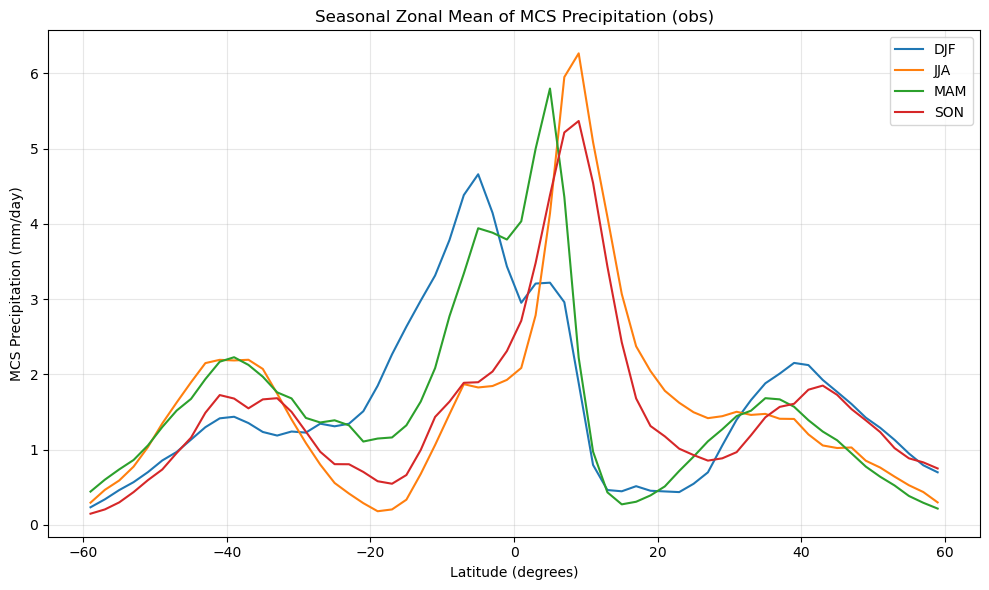

In [19]:
# Example 1: Plot zonal mean for all seasons (one source)
fig, ax = plt.subplots(figsize=(10, 6))
source_to_plot = 'obs'  # or 'm1', 'm2', etc.
for season in mcs_pcp_zonal.season.values:
    if 'source' in mcs_pcp_zonal.dims:
        mcs_pcp_zonal.sel(season=season, source=source_to_plot).plot(ax=ax, label=season)
    else:
        mcs_pcp_zonal.sel(season=season).plot(ax=ax, label=season)

ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('MCS Precipitation (mm/day)')
ax.set_title(f'Seasonal Zonal Mean of MCS Precipitation ({source_to_plot})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

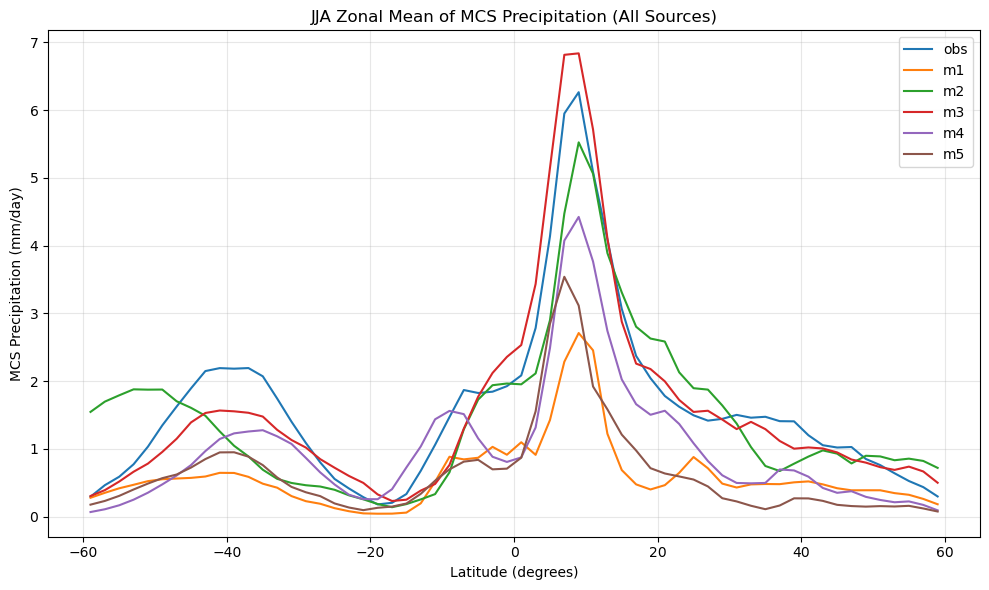


JJA 'obs' zonal mean at 10°N: 5.09 mm/day


In [20]:
# Example 2: Compare all sources for one season
if 'source' in mcs_pcp_zonal.dims:
    fig, ax = plt.subplots(figsize=(10, 6))
    season_to_plot = 'JJA'
    for source in mcs_pcp_zonal.source.values:
        mcs_pcp_zonal.sel(season=season_to_plot, source=source).plot(ax=ax, label=source)
    
    ax.set_xlabel('Latitude (degrees)')
    ax.set_ylabel('MCS Precipitation (mm/day)')
    ax.set_title(f'{season_to_plot} Zonal Mean of MCS Precipitation (All Sources)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example 3: Access specific values
if 'source' in mcs_pcp_zonal.dims:
    print(f"\nJJA 'obs' zonal mean at 10°N: {mcs_pcp_zonal.sel(season='JJA', source='obs').sel(latitude=10, method='nearest').values:.2f} mm/day")
else:
    print(f"\nJJA zonal mean at 10°N: {mcs_pcp_zonal.sel(season='JJA').sel(latitude=10, method='nearest').values:.2f} mm/day")

## Function to plot zonal mean

In [21]:
# Define color dictionary for sources
color_dict = {
    'obs': 'k', 
    'm1': 'dodgerblue', 
    'm2': 'deeppink', 
    'm3': 'green', 
    'm4': 'lime',
    'm5': 'darkorange',
}

In [22]:
def plot_zonal_mean_multisource(data_list, color_dict, panel_titles=None, 
                                 ylims=None, xlabel='Latitude (°)', ylabel='Value',
                                 suptitle=None, figsize=None, legend_loc='best',
                                 figname=None, dpi=200,
                                 obs_linewidth=2.5, model_linewidth=1.5,
                                 fontsize_title=12, fontsize_label=11, 
                                 fontsize_legend=9, fontsize_suptitle=14,
                                 ):
    """
    Plot zonal means for multiple sources in N-panel figure (one panel per dataset/season).
    
    Each panel shows multiple sources as line plots, with 'obs' line thicker than model lines.
    
    Parameters
    ----------
    data_list : list of xarray.DataArray
        List of N datasets to plot. Each should have dimensions (source, latitude).
        For example: [data.sel(season='DJF'), data.sel(season='MAM'), ...]
    color_dict : dict
        Dictionary mapping source names to colors. Keys should match 'source' coordinate.
        Example: {'obs': 'black', 'm1': 'red', 'm2': 'blue', ...}
    panel_titles : list of str, optional
        Title for each panel. Length should match data_list. 
        If None, uses season names if available, otherwise 'Panel 1', 'Panel 2', etc.
    ylims : tuple or list of tuples, optional
        Y-axis limits. Can be:
        - Single tuple (ymin, ymax) applied to all panels
        - List of tuples, one per panel for individual control
        - None for automatic limits
    xlabel : str, optional
        X-axis label (default: 'Latitude (°)')
    ylabel : str, optional
        Y-axis label (default: 'Value')
    suptitle : str, optional
        Figure super title (default: None)
    figsize : tuple, optional
        Figure size (width, height). If None, auto-calculated based on number of panels.
    legend_loc : str, optional (default: 'best')
        Location of the legend
    figname : str, optional
        Figure name to save.
    dpi : int, optional (default: 200)
        DPI for saving the figure.
    obs_linewidth : float, optional
        Line width for 'obs' source (default: 2.5)
    model_linewidth : float, optional
        Line width for model sources (default: 1.5)
    fontsize_title : int, optional
        Font size for panel titles (default: 12)
    fontsize_label : int, optional
        Font size for axis labels (default: 11)
    fontsize_legend : int, optional
        Font size for legend text (default: 9)
    fontsize_suptitle : int, optional
        Font size for super title (default: 14)
        
    Returns
    -------
    fig, axes : matplotlib Figure and Axes objects
    
    Example
    -------
    >>> color_dict = {'obs': 'black', 'm1': 'red', 'm2': 'blue', 'm3': 'green'}
    >>> data_list = [
    ...     mcs_pcpfrac_zonal.sel(season='DJF'),
    ...     mcs_pcpfrac_zonal.sel(season='MAM'),
    ...     mcs_pcpfrac_zonal.sel(season='JJA'),
    ...     mcs_pcpfrac_zonal.sel(season='SON')
    ... ]
    >>> fig, axes = plot_zonal_mean_multisource(
    ...     data_list, color_dict, 
    ...     panel_titles=['DJF', 'MAM', 'JJA', 'SON'],
    ...     ylims=(0, 50),
    ...     ylabel='MCS Precipitation Fraction (%)',
    ...     suptitle='Seasonal MCS Precipitation Fraction'
    ... )
    """

    n_panels = len(data_list)
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        fig_width = 10
        fig_height = 3 * n_panels
        figsize = (fig_width, fig_height)
    
    # Create subplots
    fig, axes = plt.subplots(n_panels, 1, figsize=figsize, sharex=True)
    
    # Ensure axes is iterable even for single panel
    if n_panels == 1:
        axes = [axes]
    
    # Generate default panel titles if not provided
    if panel_titles is None:
        # Try to get season names from data if available
        panel_titles = []
        for i, data in enumerate(data_list):
            if hasattr(data, 'season') and data.season is not None:
                panel_titles.append(str(data.season.values))
            else:
                panel_titles.append(f'Panel {i+1}')
    
    # Handle ylims - convert single tuple to list of tuples
    if ylims is not None:
        if isinstance(ylims, tuple):
            ylims = [ylims] * n_panels
    else:
        ylims = [None] * n_panels
    
    # Plot each panel
    for i, (ax, data, title, ylim) in enumerate(zip(axes, data_list, panel_titles, ylims)):
        # Get sources from data
        sources = data.source.values
        latitude = data.latitude.values
        
        # Plot each source
        for source in sources:
            # Select line width based on source
            lw = obs_linewidth if source == 'obs' else model_linewidth
            
            # Get color from dictionary
            color = color_dict.get(source, 'gray')
            
            # Plot the line
            ax.plot(latitude, data.sel(source=source).values, 
                   color=color, linewidth=lw, label=name_map_plot[source])
        
        # Formatting
        ax.set_title(title, fontsize=fontsize_title, fontweight='bold', loc='left')
        ax.set_ylabel(ylabel, fontsize=fontsize_label)
        ax.tick_params(axis='x', labelsize=fontsize_label)
        ax.tick_params(axis='y', labelsize=fontsize_label)
        ax.grid(True, alpha=0.7, linestyle=':')
        
        # Set y-limits if provided
        if ylim is not None:
            ax.set_ylim(ylim)
        
        # Add legend to first panel
        if i == 0:
            ax.legend(loc=legend_loc, framealpha=0.9, fontsize=fontsize_legend)
        
        # Only show x-label on bottom panel
        if i == n_panels - 1:
            ax.set_xlabel(xlabel, fontsize=fontsize_label)
    
    # Add super title if provided
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=fontsize_suptitle, fontweight='bold', y=0.995)
    
    plt.tight_layout()

    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    print(f'Figure saved: {figname}')
    return fig

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_mcs_all_rainfrac_4season_obs_vs_models.png


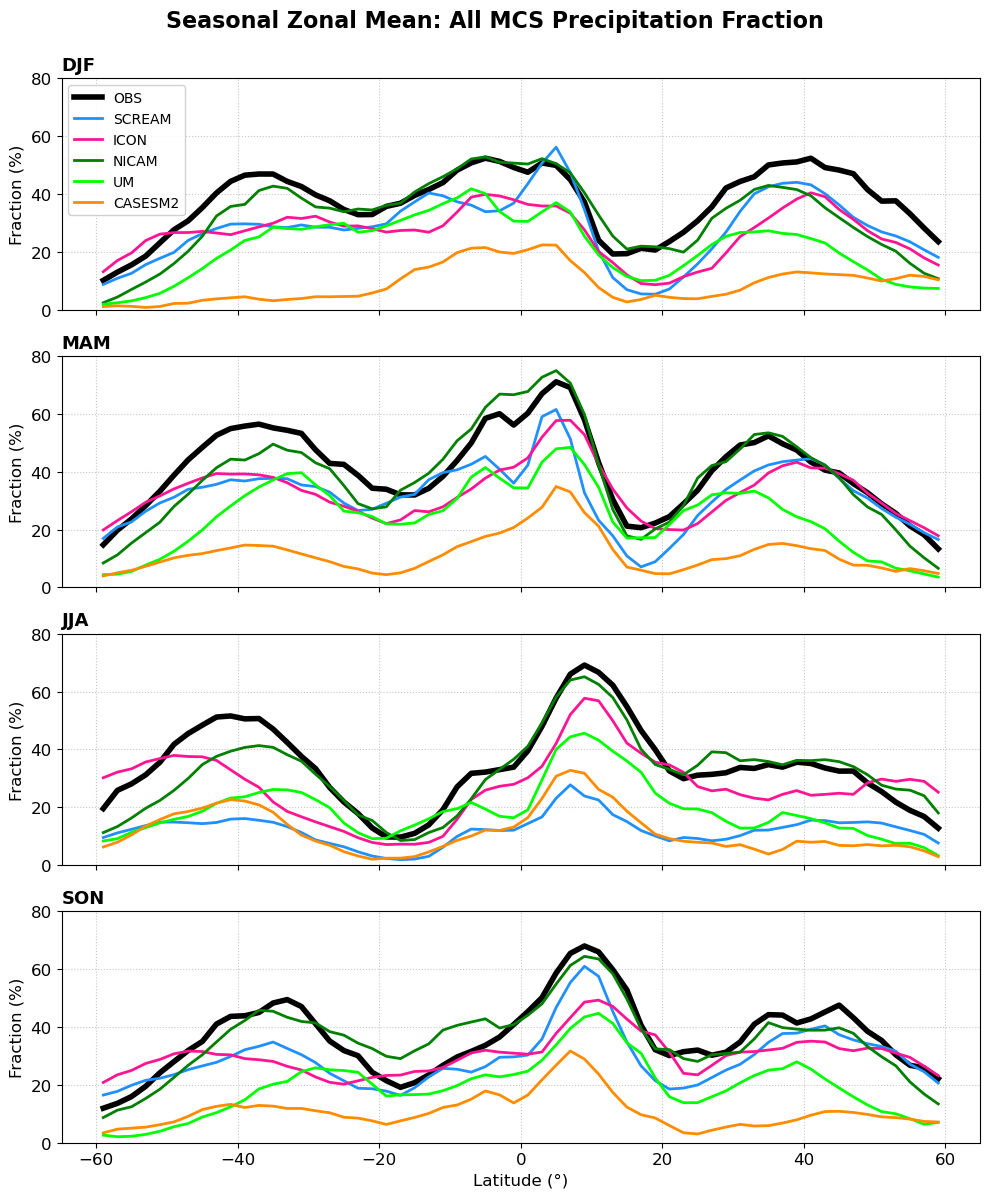

In [23]:
# Plot All MCS precipitation fraction for all 4 seasons
data_list = [
    mcs_pcpfrac_zonal.sel(season='DJF'),
    mcs_pcpfrac_zonal.sel(season='MAM'),
    mcs_pcpfrac_zonal.sel(season='JJA'),
    mcs_pcpfrac_zonal.sel(season='SON')
]
panel_titles = ['DJF', 'MAM', 'JJA', 'SON']
ylabel = 'Fraction (%)'
ylims = (0, 80)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: All MCS Precipitation Fraction'
figname = f'{figdir}zonalmean_mcs_all_rainfrac_4season_obs_vs_models.png'
figsize = (10, 12)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_mcs-iso_rainfrac_4season_obs_vs_models.png


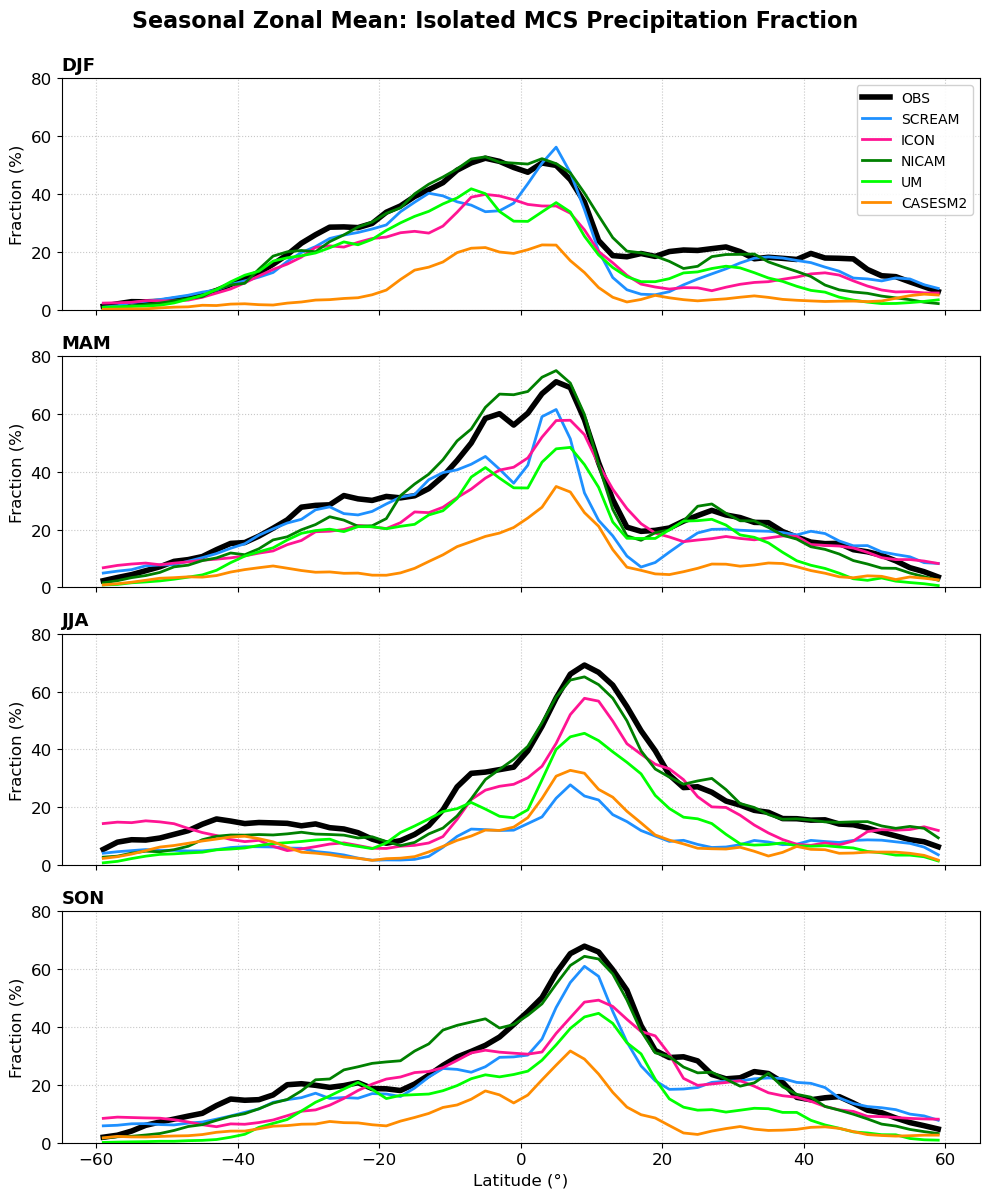

In [24]:
# Plot All MCS precipitation fraction for all 4 seasons
data_list = [
    mcs_iso_pcpfrac_zonal.sel(season='DJF'),
    mcs_iso_pcpfrac_zonal.sel(season='MAM'),
    mcs_iso_pcpfrac_zonal.sel(season='JJA'),
    mcs_iso_pcpfrac_zonal.sel(season='SON')
]
panel_titles = ['DJF', 'MAM', 'JJA', 'SON']
ylabel = 'Fraction (%)'
ylims = (0, 80)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: Isolated MCS Precipitation Fraction'
figname = f'{figdir}zonalmean_mcs-iso_rainfrac_4season_obs_vs_models.png'
figsize = (10, 12)
legend_loc = 'best'
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_mcs-ar-etc_rainfrac_4season_obs_vs_models.png


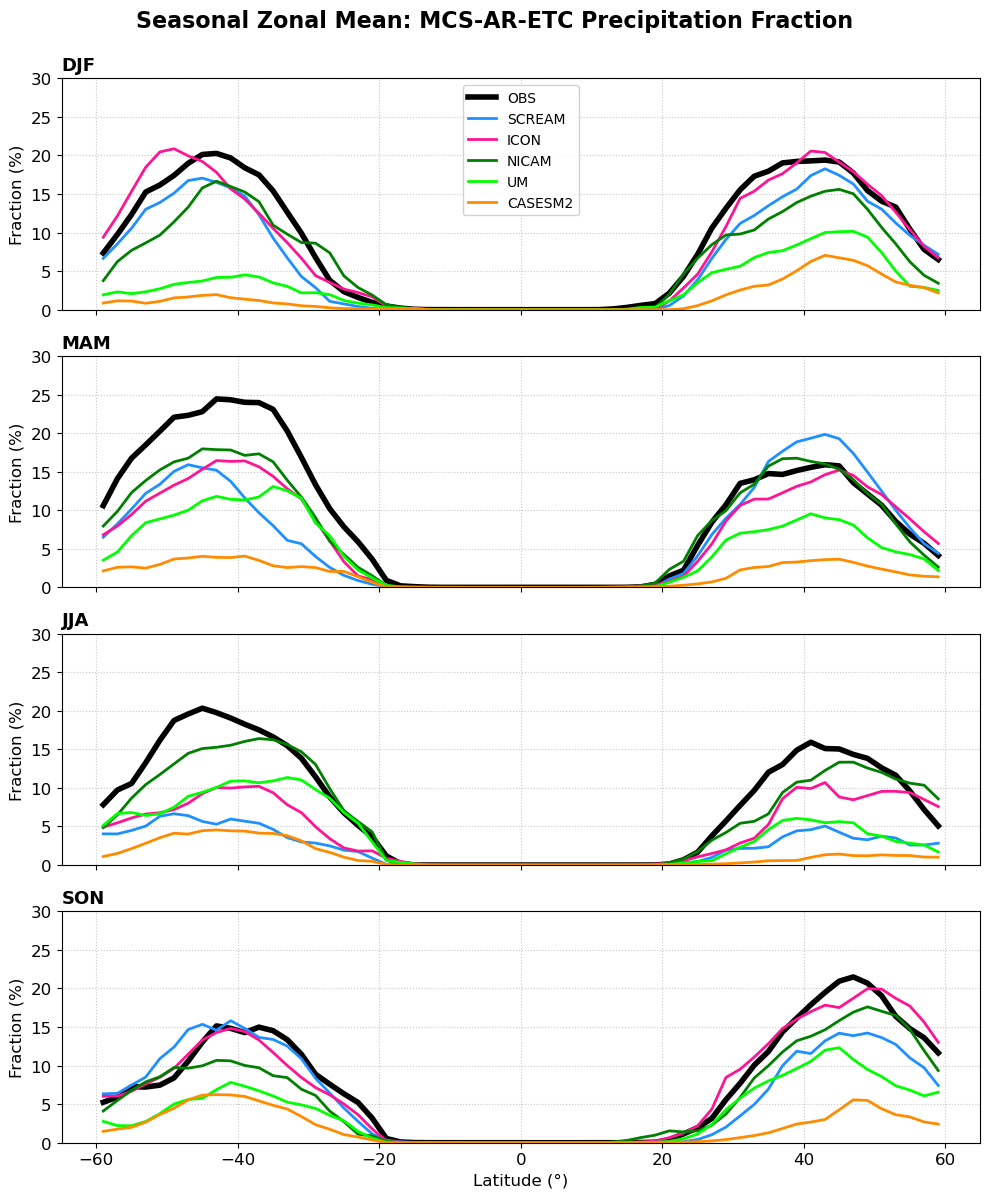

In [25]:
# Plot All MCS precipitation fraction for all 4 seasons
data_list = [
    mcs_ar_etc_pcpfrac_zonal.sel(season='DJF'),
    mcs_ar_etc_pcpfrac_zonal.sel(season='MAM'),
    mcs_ar_etc_pcpfrac_zonal.sel(season='JJA'),
    mcs_ar_etc_pcpfrac_zonal.sel(season='SON')
]
panel_titles = ['DJF', 'MAM', 'JJA', 'SON']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-AR-ETC Precipitation Fraction'
figname = f'{figdir}zonalmean_mcs-ar-etc_rainfrac_4season_obs_vs_models.png'
figsize = (10, 12)
legend_loc = 'upper center'
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2, legend_loc=legend_loc,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_mcs-ar_rainfrac_4season_obs_vs_models.png


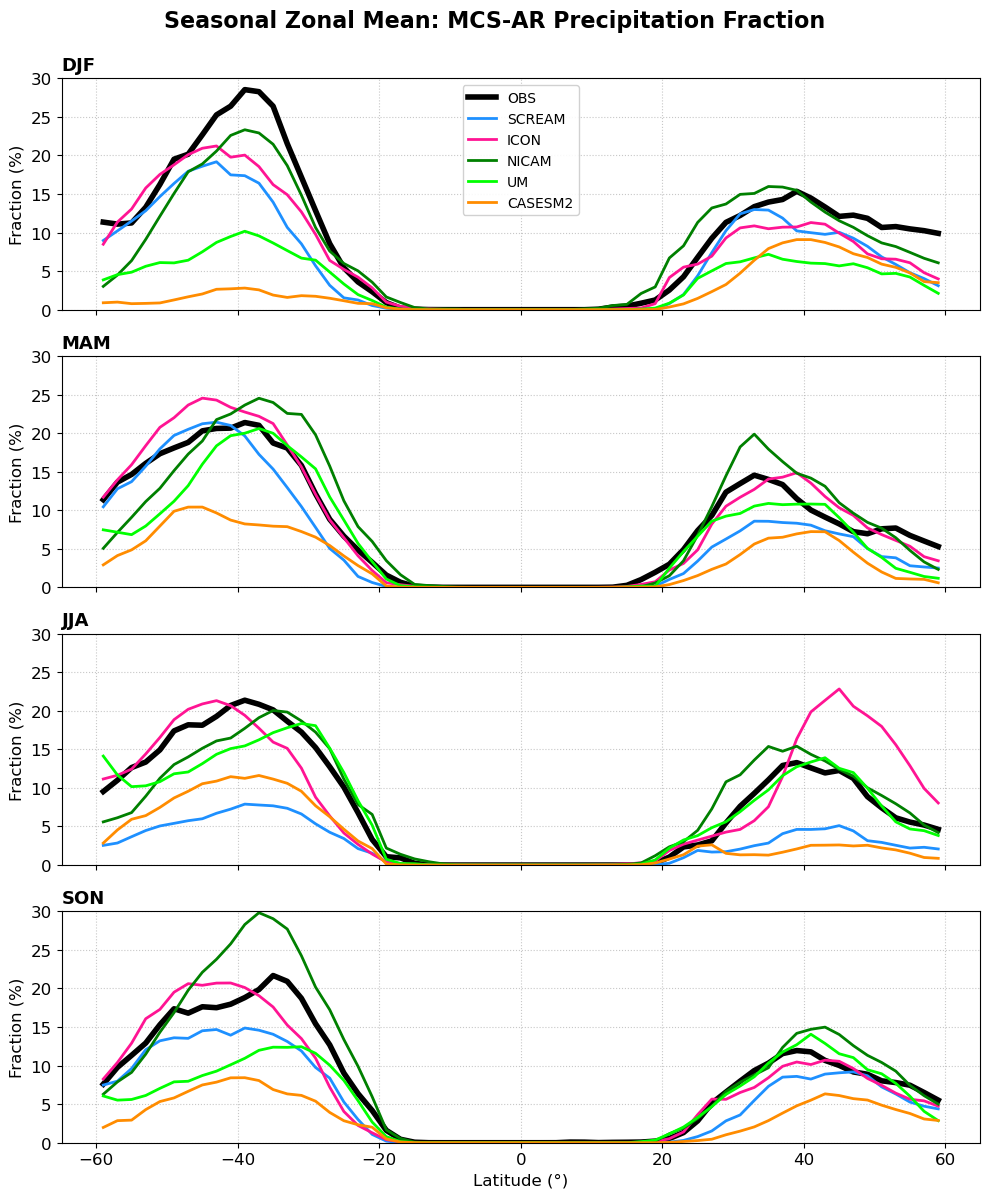

In [26]:
# Plot All MCS precipitation fraction for all 4 seasons
data_list = [
    mcs_ar_pcpfrac_zonal.sel(season='DJF'),
    mcs_ar_pcpfrac_zonal.sel(season='MAM'),
    mcs_ar_pcpfrac_zonal.sel(season='JJA'),
    mcs_ar_pcpfrac_zonal.sel(season='SON')
]
panel_titles = ['DJF', 'MAM', 'JJA', 'SON']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-AR Precipitation Fraction'
figname = f'{figdir}zonalmean_mcs-ar_rainfrac_4season_obs_vs_models.png'
figsize = (10, 12)
legend_loc = 'upper center'
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2, legend_loc=legend_loc,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_mcs-etc_rainfrac_4season_obs_vs_models.png


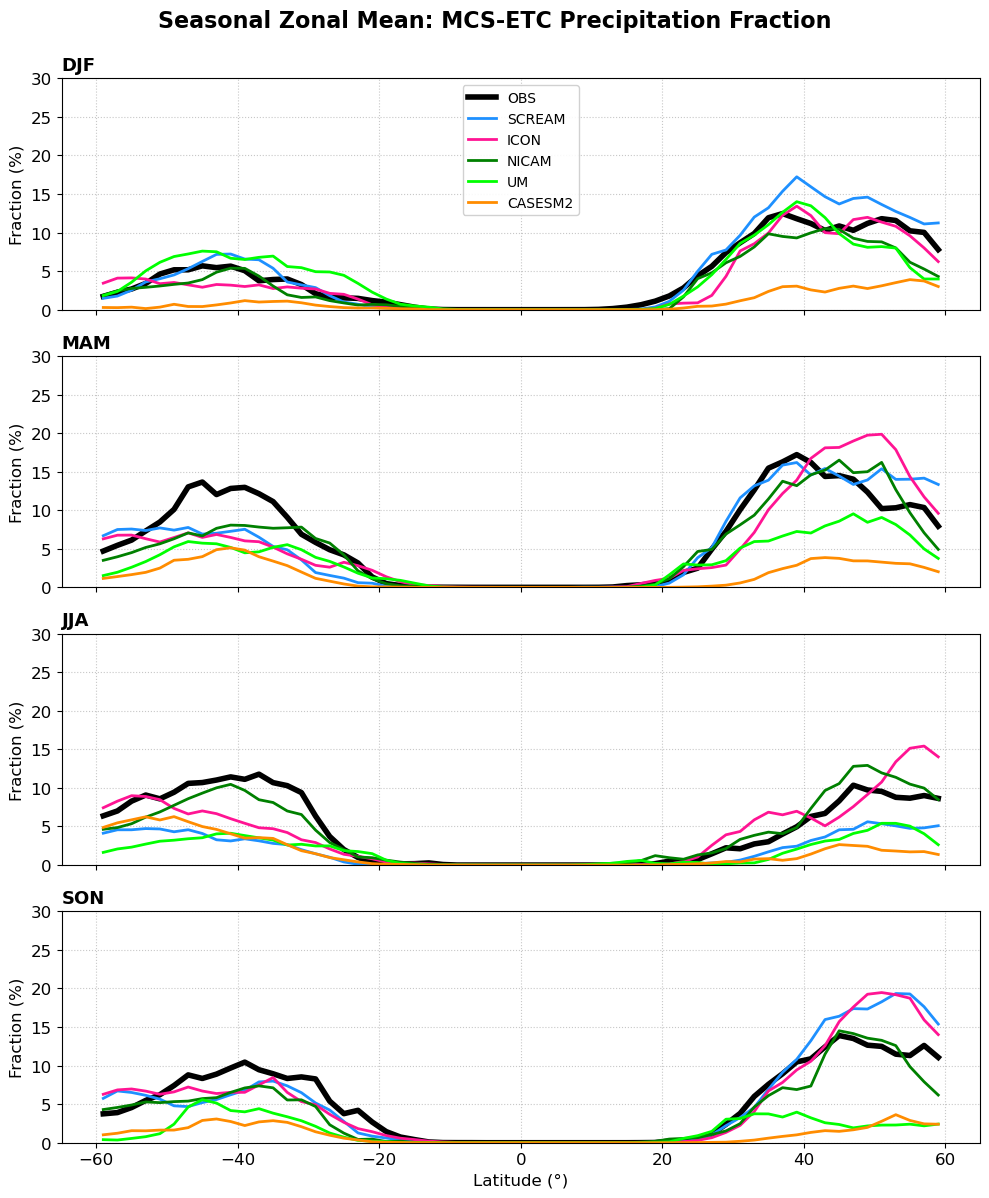

In [27]:
# Plot All MCS precipitation fraction for all 4 seasons
data_list = [
    mcs_etc_pcpfrac_zonal.sel(season='DJF'),
    mcs_etc_pcpfrac_zonal.sel(season='MAM'),
    mcs_etc_pcpfrac_zonal.sel(season='JJA'),
    mcs_etc_pcpfrac_zonal.sel(season='SON')
]
panel_titles = ['DJF', 'MAM', 'JJA', 'SON']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-ETC Precipitation Fraction'
figname = f'{figdir}zonalmean_mcs-etc_rainfrac_4season_obs_vs_models.png'
figsize = (10, 12)
legend_loc = 'upper center'
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2, legend_loc=legend_loc,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

### Plot zonal mean separately for land vs. ocean

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_ocean_mcs_all_rainfrac_4season_obs_vs_models.png


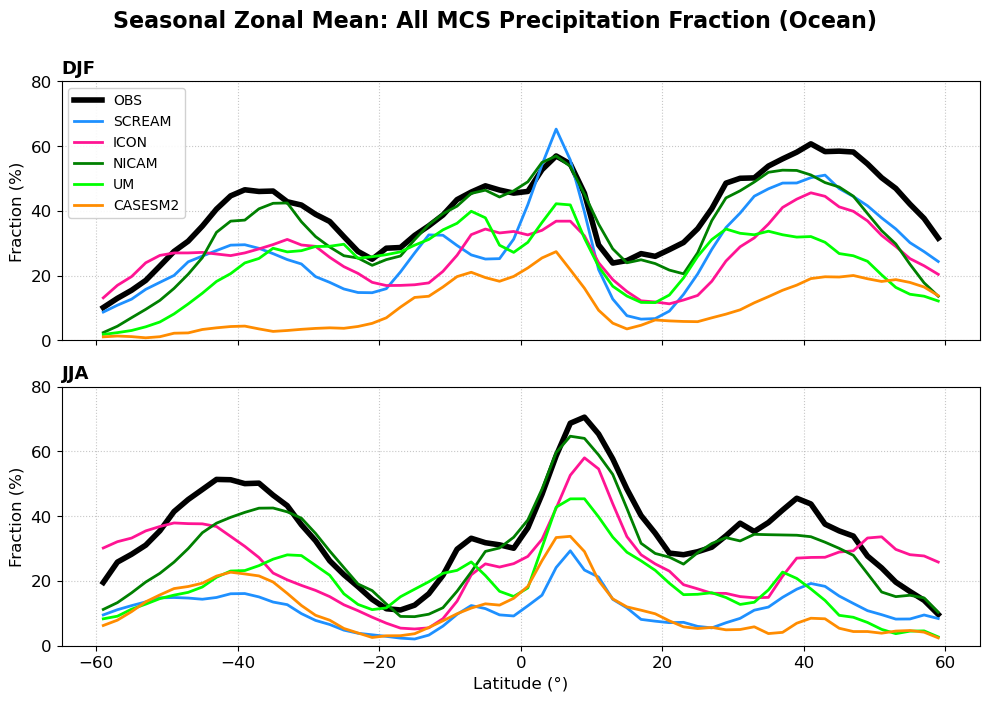

In [28]:
data_list = [
    mcs_pcpfrac_zonal_ocean.sel(season='DJF'),
    # mcs_pcpfrac_zonal_ocean.sel(season='MAM'),
    mcs_pcpfrac_zonal_ocean.sel(season='JJA'),
    # mcs_pcpfrac_zonal_ocean.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 80)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: All MCS Precipitation Fraction (Ocean)'
figname = f'{figdir}zonalmean_ocean_mcs_all_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_land_mcs_all_rainfrac_4season_obs_vs_models.png


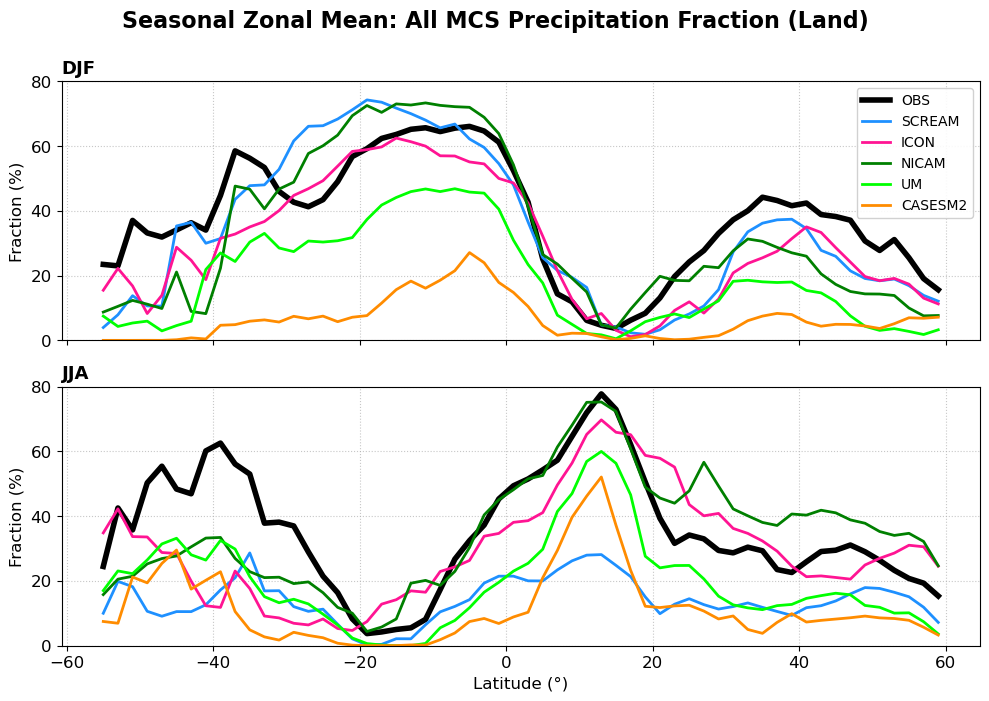

In [29]:
data_list = [
    mcs_pcpfrac_zonal_land.sel(season='DJF'),
    # mcs_pcpfrac_zonal_land.sel(season='MAM'),
    mcs_pcpfrac_zonal_land.sel(season='JJA'),
    # mcs_pcpfrac_zonal_land.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 80)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: All MCS Precipitation Fraction (Land)'
figname = f'{figdir}zonalmean_land_mcs_all_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_ocean_mcs_iso_rainfrac_4season_obs_vs_models.png


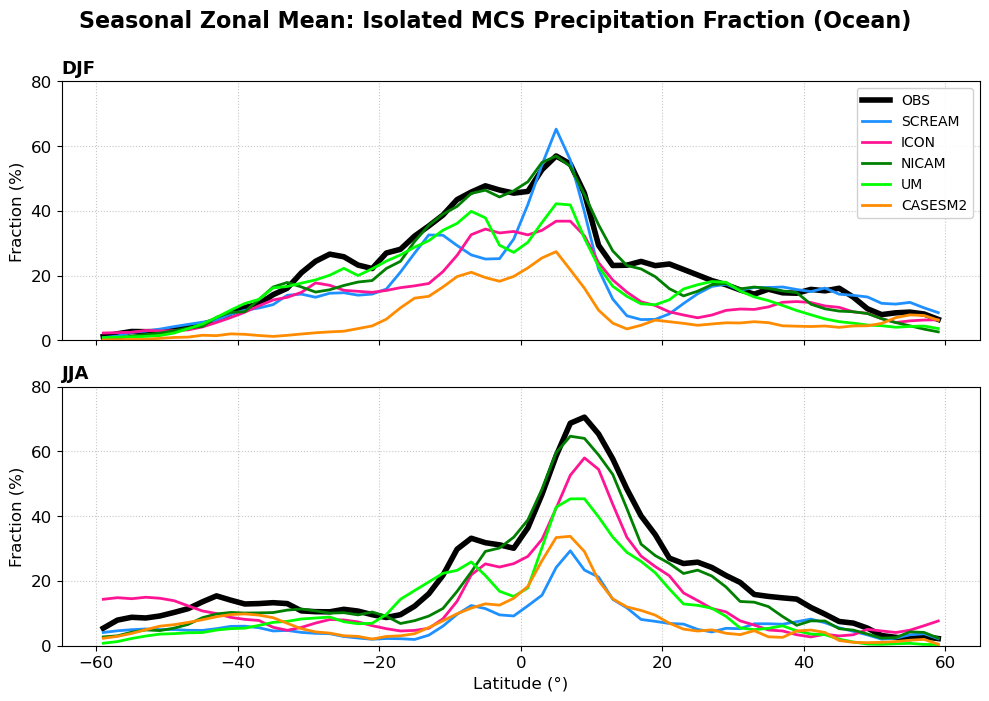

In [30]:
data_list = [
    mcs_iso_pcpfrac_zonal_ocean.sel(season='DJF'),
    # mcs_iso_pcpfrac_zonal_ocean.sel(season='MAM'),
    mcs_iso_pcpfrac_zonal_ocean.sel(season='JJA'),
    # mcs_iso_pcpfrac_zonal_ocean.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 80)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: Isolated MCS Precipitation Fraction (Ocean)'
figname = f'{figdir}zonalmean_ocean_mcs_iso_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_land_mcs_iso_rainfrac_4season_obs_vs_models.png


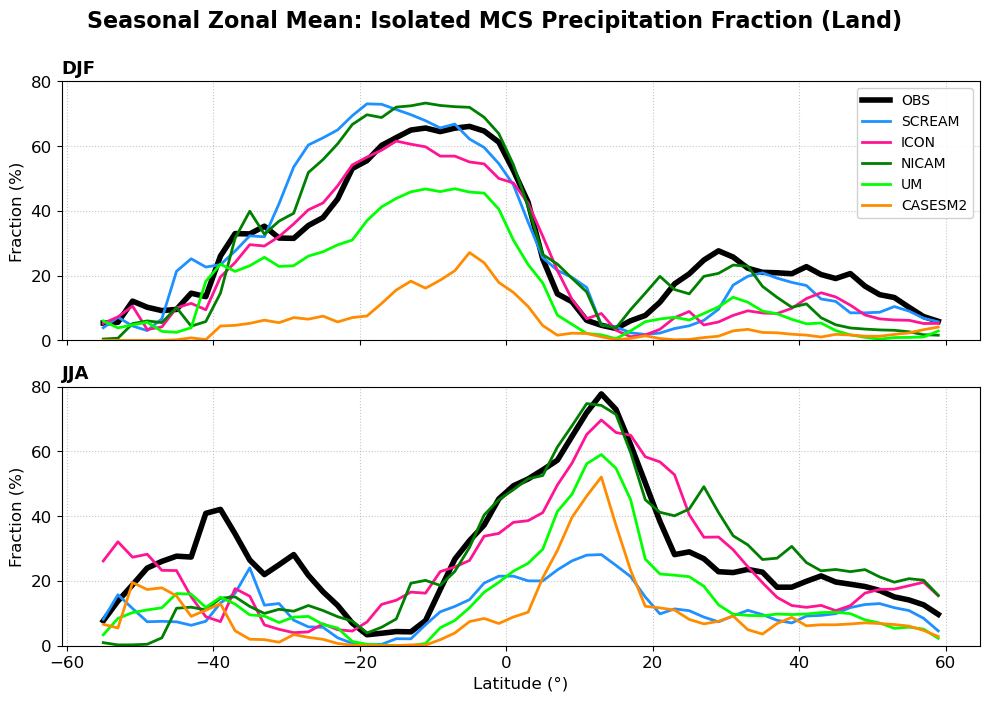

In [31]:
data_list = [
    mcs_iso_pcpfrac_zonal_land.sel(season='DJF'),
    # mcs_iso_pcpfrac_zonal_land.sel(season='MAM'),
    mcs_iso_pcpfrac_zonal_land.sel(season='JJA'),
    # mcs_iso_pcpfrac_zonal_land.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 80)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: Isolated MCS Precipitation Fraction (Land)'
figname = f'{figdir}zonalmean_land_mcs_iso_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_ocean_mcs_ar_etc_rainfrac_4season_obs_vs_models.png


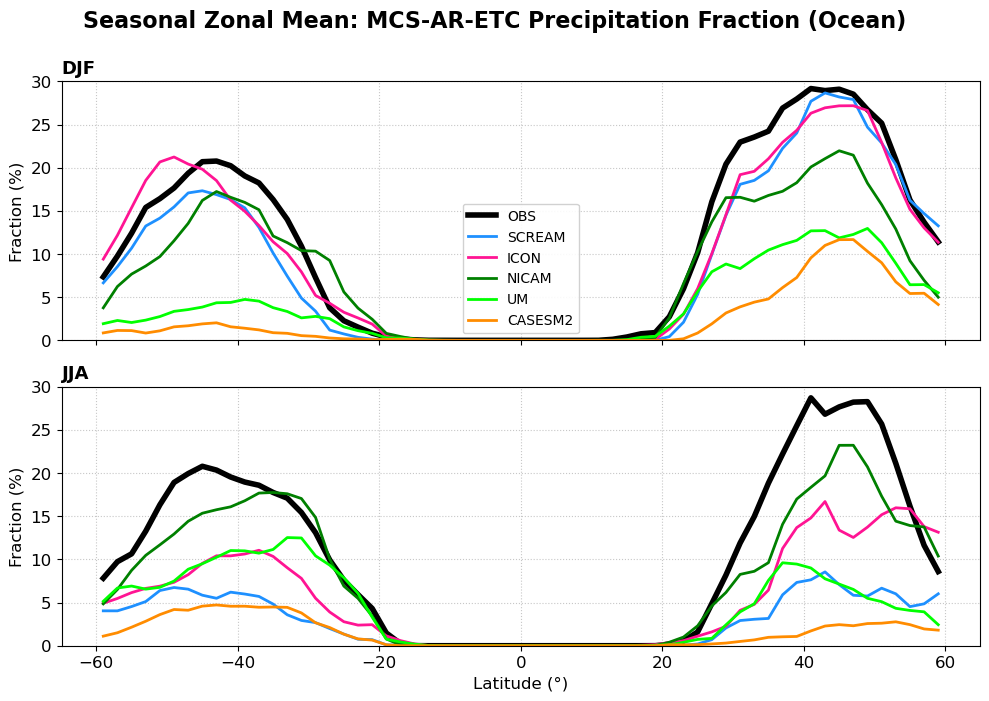

In [32]:
data_list = [
    mcs_ar_etc_pcpfrac_zonal_ocean.sel(season='DJF'),
    # mcs_ar_etc_pcpfrac_zonal_ocean.sel(season='MAM'),
    mcs_ar_etc_pcpfrac_zonal_ocean.sel(season='JJA'),
    # mcs_ar_etc_pcpfrac_zonal_ocean.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-AR-ETC Precipitation Fraction (Ocean)'
figname = f'{figdir}zonalmean_ocean_mcs_ar_etc_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_land_mcs_ar_etc_rainfrac_4season_obs_vs_models.png


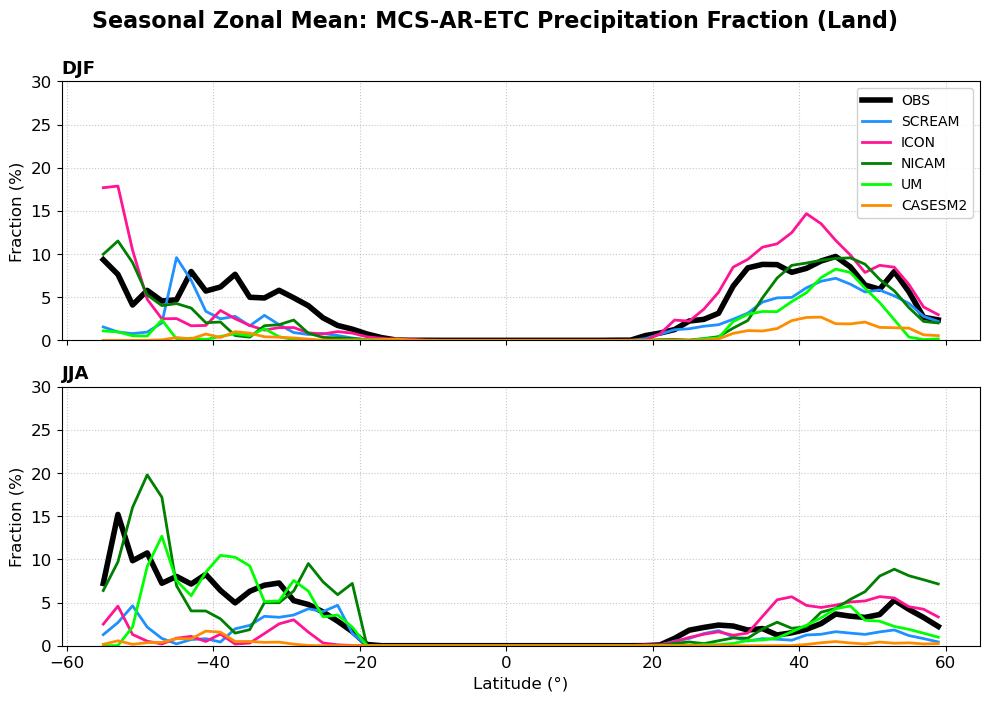

In [33]:
data_list = [
    mcs_ar_etc_pcpfrac_zonal_land.sel(season='DJF'),
    # mcs_ar_etc_pcpfrac_zonal_land.sel(season='MAM'),
    mcs_ar_etc_pcpfrac_zonal_land.sel(season='JJA'),
    # mcs_ar_etc_pcpfrac_zonal_land.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-AR-ETC Precipitation Fraction (Land)'
figname = f'{figdir}zonalmean_land_mcs_ar_etc_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_ocean_mcs_ar_rainfrac_4season_obs_vs_models.png


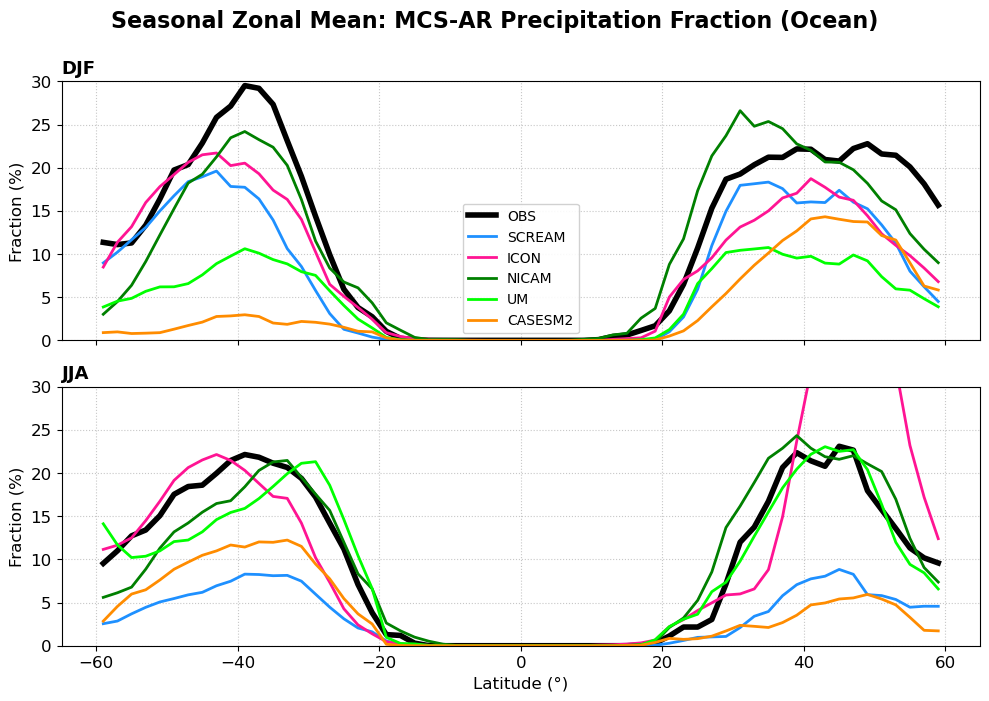

In [34]:
data_list = [
    mcs_ar_pcpfrac_zonal_ocean.sel(season='DJF'),
    # mcs_ar_pcpfrac_zonal_ocean.sel(season='MAM'),
    mcs_ar_pcpfrac_zonal_ocean.sel(season='JJA'),
    # mcs_ar_pcpfrac_zonal_ocean.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-AR Precipitation Fraction (Ocean)'
figname = f'{figdir}zonalmean_ocean_mcs_ar_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_land_mcs_ar_rainfrac_4season_obs_vs_models.png


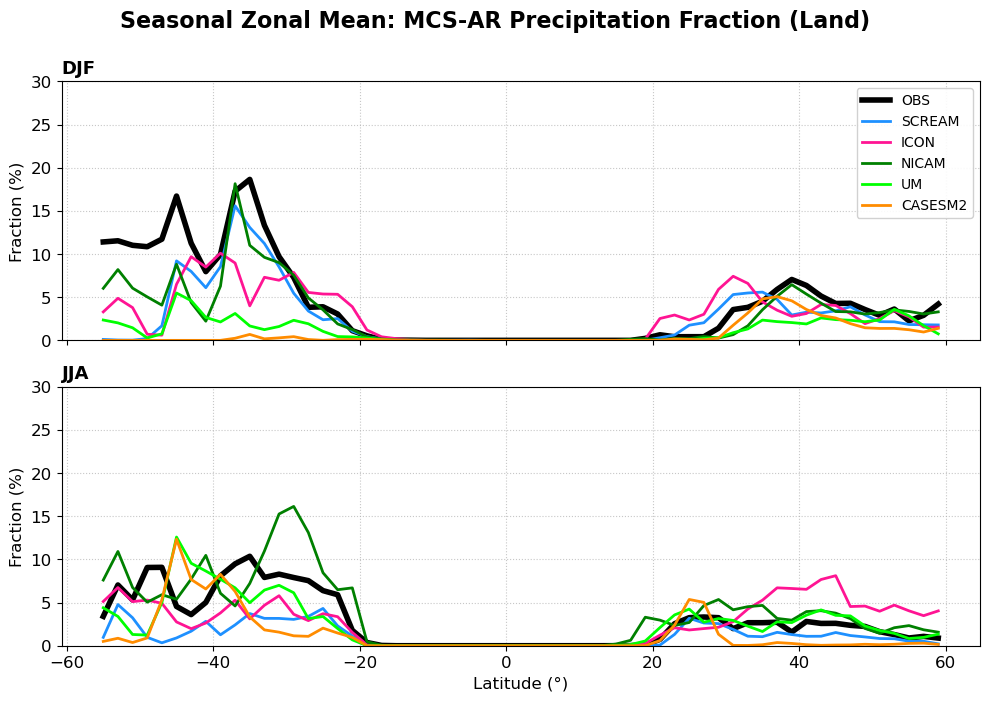

In [35]:
data_list = [
    mcs_ar_pcpfrac_zonal_land.sel(season='DJF'),
    # mcs_ar_pcpfrac_zonal_land.sel(season='MAM'),
    mcs_ar_pcpfrac_zonal_land.sel(season='JJA'),
    # mcs_ar_pcpfrac_zonal_land.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-AR Precipitation Fraction (Land)'
figname = f'{figdir}zonalmean_land_mcs_ar_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_ocean_mcs_etc_rainfrac_4season_obs_vs_models.png


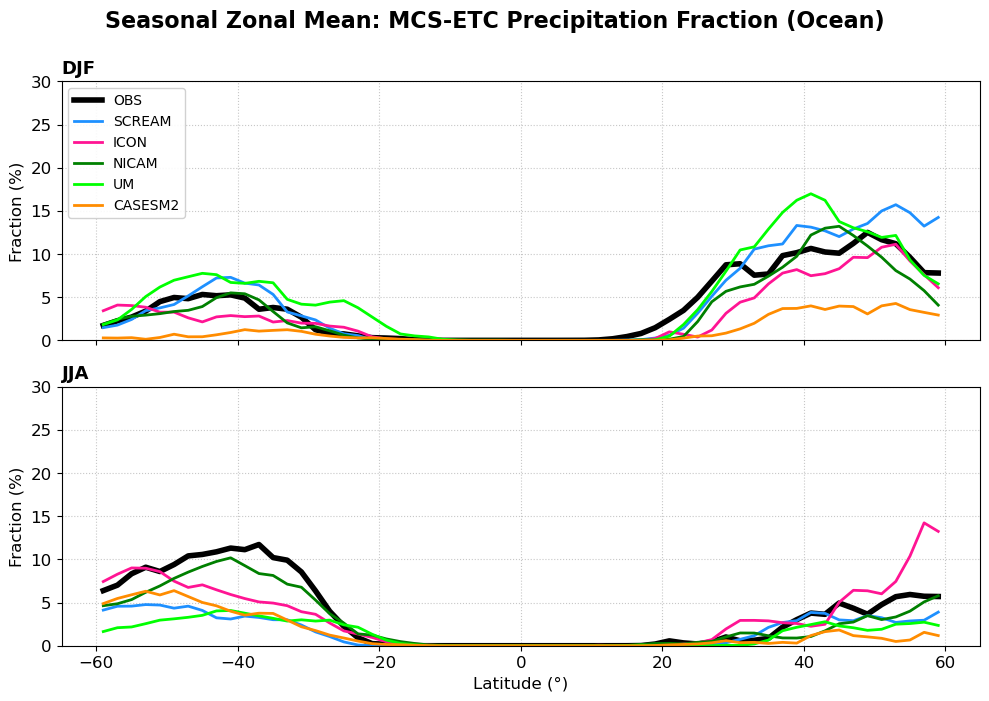

In [36]:
data_list = [
    mcs_etc_pcpfrac_zonal_ocean.sel(season='DJF'),
    # mcs_etc_pcpfrac_zonal_ocean.sel(season='MAM'),
    mcs_etc_pcpfrac_zonal_ocean.sel(season='JJA'),
    # mcs_etc_pcpfrac_zonal_ocean.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-ETC Precipitation Fraction (Ocean)'
figname = f'{figdir}zonalmean_ocean_mcs_etc_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_cof/zonalmean_land_mcs_etc_rainfrac_4season_obs_vs_models.png


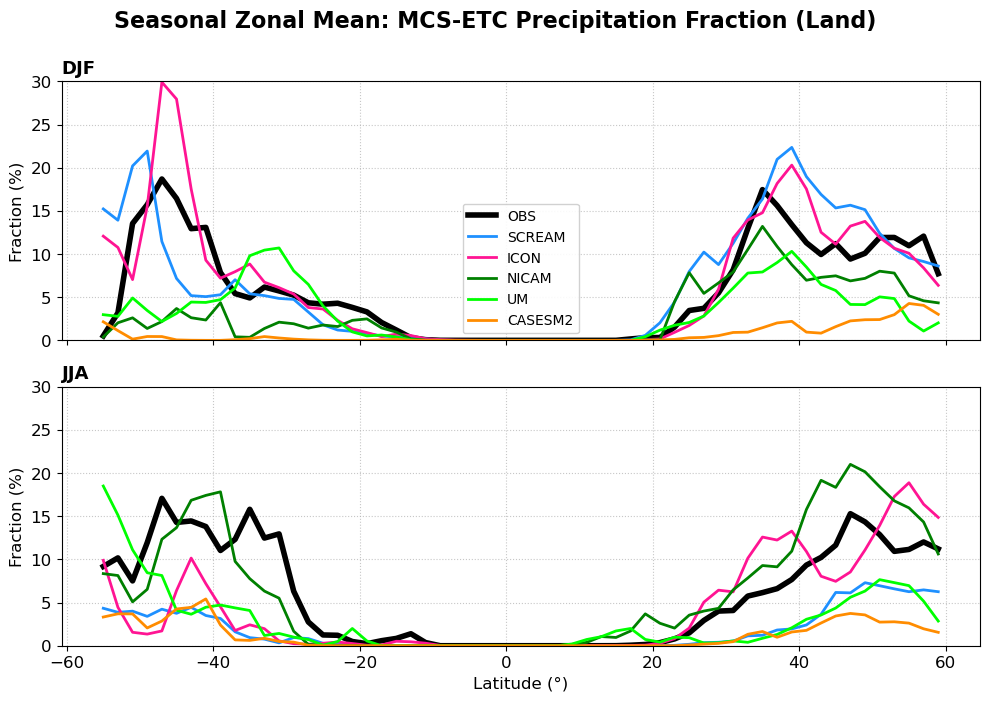

In [37]:
data_list = [
    mcs_etc_pcpfrac_zonal_land.sel(season='DJF'),
    # mcs_etc_pcpfrac_zonal_land.sel(season='MAM'),
    mcs_etc_pcpfrac_zonal_land.sel(season='JJA'),
    # mcs_etc_pcpfrac_zonal_land.sel(season='SON')
]
panel_titles = ['DJF', 'JJA']
ylabel = 'Fraction (%)'
ylims = (0, 30)    # Same y-limits for all panels
suptitle = 'Seasonal Zonal Mean: MCS-ETC Precipitation Fraction (Land)'
figname = f'{figdir}zonalmean_land_mcs_etc_rainfrac_4season_obs_vs_models.png'
figsize = (10, 7)
xlabel = 'Latitude (°)'

fig = plot_zonal_mean_multisource(data_list, color_dict,
    panel_titles=panel_titles, ylims=ylims, xlabel=xlabel, ylabel=ylabel, suptitle=suptitle,
    figsize=figsize, figname=figname, obs_linewidth=4, model_linewidth=2,
    fontsize_title=13, fontsize_label=12, fontsize_legend=10, fontsize_suptitle=16,
)

In [ ]:
tropics_lat = [-20, 20]
# extratropics_lat = [-90, -20, 20, 90]
tc_lat = [-40, 40]

tot_pcp_all_trop = tot_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
tot_pcp_all_extrop = tot_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

# Filter features for different latitude bands
# Original features
mcs_freq_all_trop = mcs_freq_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_freq_all_extrop = mcs_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_pcp_all_trop = mcs_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_pcp_all_extrop = mcs_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

tc_freq_all_trop = tc_freq_all.where((hp_lat >= min(tc_lat)) & (hp_lat <= max(tc_lat)))
tc_pcp_all_trop = tc_pcp_all.where((hp_lat >= min(tc_lat)) & (hp_lat <= max(tc_lat)))

# Isolated features only
mcs_iso_freq_all_trop = mcs_iso_freq_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_iso_pcp_all_trop = mcs_iso_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
mcs_iso_pcp_all_extrop = mcs_iso_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

ar_iso_freq_all_extrop = ar_iso_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
ar_iso_pcp_all_extrop = ar_iso_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

etc_iso_freq_all_extrop = etc_iso_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
etc_iso_pcp_all_extrop = etc_iso_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

# Cloud types (not tracked)
dc_freq_all_trop = dc_freq_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
dc_pcp_all_trop = dc_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
dc_freq_all_extrop = dc_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
dc_pcp_all_extrop = dc_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

nd_freq_all_trop = nd_freq_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
nd_pcp_all_trop = nd_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
nd_freq_all_extrop = nd_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
nd_pcp_all_extrop = nd_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

st_freq_all_trop = st_freq_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
st_pcp_all_trop = st_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
st_freq_all_extrop = st_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
st_pcp_all_extrop = st_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

dz_freq_all_trop = dz_freq_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
dz_pcp_all_trop = dz_pcp_all.where((hp_lat >= min(tropics_lat)) & (hp_lat <= max(tropics_lat)))
dz_freq_all_extrop = dz_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
dz_pcp_all_extrop = dz_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

# Co-occurrence features
mcs_ar_freq_all_extrop = mcs_ar_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_ar_pcp_all_extrop = mcs_ar_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_ar_pcpfrac_all_extrop = mcs_ar_pcpfrac_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

mcs_etc_freq_all_extrop = mcs_etc_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_etc_pcp_all_extrop = mcs_etc_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_etc_pcpfrac_all_extrop = mcs_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

ar_etc_freq_all_extrop = ar_etc_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
ar_etc_pcp_all_extrop = ar_etc_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
ar_etc_pcpfrac_all_extrop = ar_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

mcs_ar_etc_freq_all_extrop = mcs_ar_etc_freq_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_ar_etc_pcp_all_extrop = mcs_ar_etc_pcp_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))
mcs_ar_etc_pcpfrac_all_extrop = mcs_ar_etc_pcpfrac_all.where((hp_lat < min(tropics_lat)) | (hp_lat > max(tropics_lat)))

In [ ]:
# im = egh.healpix_show(tot_pcp_all_trop.sel(source='obs'), vmin=0, vmax=12, cmap=cmaps.WhBlGrYeRe)
im = egh.healpix_show(tot_pcp_all_extrop.sel(source='obs'), vmin=0, vmax=8, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='Total Precipitation (mm/day)')

In [ ]:
im = egh.healpix_show(mcs_ar_pcp_all_extrop.sel(source='obs'), vmin=0, vmax=4, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='MCS-AR Precipitation (mm/day)')

In [ ]:
im = egh.healpix_show(mcs_ar_etc_pcp_all_extrop.sel(source='obs'), vmin=0, vmax=4, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='MCS-AR-ETC Precipitation (mm/day)')

In [ ]:
im = egh.healpix_show(dc_pcp_all_trop.sel(source='m4'), vmin=0, vmax=4, cmap=cmaps.WhBlGrYeRe)
plt.colorbar(im, orientation='horizontal', pad=0.05, label='DC Tropics Precipitation (mm/day)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 40.1, 5)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(dc_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='DC Precipitation Fraction (%)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 40.1, 5)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(st_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='DC Precipitation Fraction (%)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 40.1, 5)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(nd_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='ND Precipitation Fraction (%)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
levels = np.arange(0, 40.1, 5)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(dz_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='DZ Precipitation Fraction (%)')

In [ ]:
# Compute global mean values
# Original features
mcs_freq_all_avg = mcs_freq_all.mean(dim='cell').compute()
mcs_freq_all_trop_avg = mcs_freq_all_trop.mean(dim='cell').compute()
mcs_freq_all_extrop_avg = mcs_freq_all_extrop.mean(dim='cell').compute()

mcs_pcp_all_avg = mcs_pcp_all.mean(dim='cell').compute()
mcs_pcp_all_trop_avg = mcs_pcp_all_trop.mean(dim='cell').compute()
mcs_pcp_all_extrop_avg = mcs_pcp_all_extrop.mean(dim='cell').compute()

tc_freq_all_trop_avg = tc_freq_all_trop.mean(dim='cell').compute()
tc_pcp_all_trop_avg = tc_pcp_all_trop.mean(dim='cell').compute()

# Isolated features only
mcs_iso_freq_all_trop_avg = mcs_iso_freq_all_trop.mean(dim='cell').compute()
mcs_iso_pcp_all_trop_avg = mcs_iso_pcp_all_trop.mean(dim='cell').compute()
mcs_iso_pcp_all_extrop_avg = mcs_iso_pcp_all_extrop.mean(dim='cell').compute()

ar_iso_freq_all_extrop_avg = ar_iso_freq_all_extrop.mean(dim='cell').compute()
ar_iso_pcp_all_extrop_avg = ar_iso_pcp_all_extrop.mean(dim='cell').compute()

etc_iso_freq_all_extrop_avg = etc_iso_freq_all_extrop.mean(dim='cell').compute()
etc_iso_pcp_all_extrop_avg = etc_iso_pcp_all_extrop.mean(dim='cell').compute()

# Co-occurrence features
mcs_ar_freq_all_extrop_avg = mcs_ar_freq_all_extrop.mean(dim='cell').compute()
mcs_ar_pcp_all_extrop_avg = mcs_ar_pcp_all_extrop.mean(dim='cell').compute()

mcs_etc_freq_all_extrop_avg = mcs_etc_freq_all_extrop.mean(dim='cell').compute()
mcs_etc_pcp_all_extrop_avg = mcs_etc_pcp_all_extrop.mean(dim='cell').compute()

ar_etc_freq_all_extrop_avg = ar_etc_freq_all_extrop.mean(dim='cell').compute()
ar_etc_pcp_all_extrop_avg = ar_etc_pcp_all_extrop.mean(dim='cell').compute()

mcs_ar_etc_freq_all_extrop_avg = mcs_ar_etc_freq_all_extrop.mean(dim='cell').compute()
mcs_ar_etc_pcp_all_extrop_avg = mcs_ar_etc_pcp_all_extrop.mean(dim='cell').compute()

# Cloud types (not tracked)
dc_freq_all_trop_avg = dc_freq_all_trop.mean(dim='cell').compute()
dc_pcp_all_trop_avg = dc_pcp_all_trop.mean(dim='cell').compute()
dc_freq_all_extrop_avg = dc_freq_all_extrop.mean(dim='cell').compute()
dc_pcp_all_extrop_avg = dc_pcp_all_extrop.mean(dim='cell').compute()

nd_freq_all_trop_avg = nd_freq_all_trop.mean(dim='cell').compute()
nd_pcp_all_trop_avg = nd_pcp_all_trop.mean(dim='cell').compute()
nd_freq_all_extrop_avg = nd_freq_all_extrop.mean(dim='cell').compute()
nd_pcp_all_extrop_avg = nd_pcp_all_extrop.mean(dim='cell').compute()

st_freq_all_trop_avg = st_freq_all_trop.mean(dim='cell').compute()
st_pcp_all_trop_avg = st_pcp_all_trop.mean(dim='cell').compute()
st_freq_all_extrop_avg = st_freq_all_extrop.mean(dim='cell').compute()
st_pcp_all_extrop_avg = st_pcp_all_extrop.mean(dim='cell').compute()

dz_freq_all_trop_avg = dz_freq_all_trop.mean(dim='cell').compute()
dz_pcp_all_trop_avg = dz_pcp_all_trop.mean(dim='cell').compute()
dz_freq_all_extrop_avg = dz_freq_all_extrop.mean(dim='cell').compute()
dz_pcp_all_extrop_avg = dz_pcp_all_extrop.mean(dim='cell').compute()

In [ ]:
# All MCS precipitation fractions
mcs_pcpfrac_all_avg = 100 * (mcs_pcp_all.sum(dim='cell') / tot_pcp_all.sum(dim='cell')).compute()
mcs_pcpfrac_all_trop_avg = 100 * (mcs_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
mcs_pcpfrac_all_extrop_avg = 100 * (mcs_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

# Extratropics isolated & co-occurring MCS precipitation fractions
mcs_iso_pcpfrac_all_extrop_avg = 100 * (mcs_iso_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
mcs_ar_pcpfrac_all_extrop_avg = 100 * (mcs_ar_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
mcs_etc_pcpfrac_all_extrop_avg = 100 * (mcs_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
mcs_ar_etc_pcpfrac_all_extrop_avg = 100 * (mcs_ar_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

ar_etc_pcpfrac_all_extrop_avg = 100 * (ar_etc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

# Cloud types
dc_pcpfrac_all_trop_avg = 100 * (dc_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
dc_pcpfrac_all_extrop_avg = 100 * (dc_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
nd_pcpfrac_all_trop_avg = 100 * (nd_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
nd_pcpfrac_all_extrop_avg = 100 * (nd_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
st_pcpfrac_all_trop_avg = 100 * (st_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
st_pcpfrac_all_extrop_avg = 100 * (st_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()
dz_pcpfrac_all_trop_avg = 100 * (dz_pcp_all_trop.sum(dim='cell') / tot_pcp_all_trop.sum(dim='cell')).compute()
dz_pcpfrac_all_extrop_avg = 100 * (dz_pcp_all_extrop.sum(dim='cell') / tot_pcp_all_extrop.sum(dim='cell')).compute()

In [ ]:
# Total number of precipitation types
# Isolated features only
total_iso_pcp_all = mcs_iso_pcp_all + ar_iso_pcp_all + etc_iso_pcp_all + tc_pcp_all
# Co-occurrence features
total_cof_pcp_all = mcs_ar_pcp_all + ar_etc_pcp_all + mcs_etc_pcp_all + mcs_ar_etc_pcp_all
# Cloud types (not tracked)
total_cloudtypes_pcp_all = dc_pcp_all + nd_pcp_all + st_pcp_all + dz_pcp_all
# All features
total_feature_pcp_all = total_iso_pcp_all + total_cof_pcp_all + total_cloudtypes_pcp_all
# Residual precipitation not accounted for by identified features
res_pcp_all = tot_pcp_all - total_iso_pcp_all - total_cof_pcp_all - total_cloudtypes_pcp_all

# Precipitation fractions
res_pcpfrac_all = 100. * res_pcp_all / tot_pcp_all
total_feature_pcpfrac_all = 100. * total_feature_pcp_all / tot_pcp_all

In [ ]:
# mcs_iso_pcpfrac_all, ar_iso_pcpfrac_all, etc_iso_pcpfrac_all, tc_pcpfrac_all, 
# mcs_ar_pcpfrac_all, ar_etc_pcpfrac_all, mcs_etc_pcpfrac_all, mcs_ar_etc_pcpfrac_all, re_pcpfrac_all

# mcs_iso_pcp_all, ar_iso_pcp_all, etc_iso_pcp_all, tc_pcp_all, 
# mcs_ar_pcp_all, ar_etc_pcp_all, mcs_etc_pcp_all, mcs_ar_etc_pcp_all, re_pcp_all.

In [ ]:
# Sum of isolated feature precipitation fractions
total_iso_pcpfrac_all = mcs_iso_pcpfrac_all + ar_iso_pcpfrac_all + etc_iso_pcpfrac_all + tc_pcpfrac_all
# Sum of co-occurring feature precipitation fractions
total_cof_pcpfrac_all = mcs_ar_pcpfrac_all + ar_etc_pcpfrac_all + mcs_etc_pcpfrac_all + mcs_ar_etc_pcpfrac_all
# Sum of cloud type precipitation fractions
total_cloudtypes_pcpfrac_all = dc_pcpfrac_all + nd_pcpfrac_all + st_pcpfrac_all + dz_pcpfrac_all
# Total precipitation fraction accounted for by identified features
total_sum_pcpfrac_all = total_iso_pcpfrac_all + total_cof_pcpfrac_all + total_cloudtypes_pcpfrac_all

In [ ]:
# colormaps = cmaps.WhiteBlueGreenYellowRed
# # colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
# levels = np.arange(95, 105.1, 1)
# norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

# img = egh.healpix_show(total_sum_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
# plt.colorbar(img, orientation='horizontal', pad=0.05, label='Sum of All Features Rain Fraction (%)')

colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
levels = np.arange(0, 110.1, 10)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(total_sum_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='Sum of All Features Rain Fraction (%)')

In [ ]:
colormaps = cmaps.WhiteBlueGreenYellowRed
# colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
levels = np.arange(0, 100.1, 10)
norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

img = egh.healpix_show(mcs_pcpfrac_all.sel(source='m4'), cmap=colormaps, norm=norm)
plt.colorbar(img, orientation='horizontal', pad=0.05, label='MCS Precipitation Fraction (%)')

In [ ]:
# colormaps = cmaps.WhiteBlueGreenYellowRed
# # colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
# levels = np.arange(0, 100.1, 10)
# norm = colors.BoundaryNorm(boundaries=levels, ncolors=colormaps.N)

# img = egh.healpix_show(total_feature_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
# plt.colorbar(img, orientation='horizontal', pad=0.05, label='All Features Precipitation Fraction (%)')

In [ ]:
# img = egh.healpix_show(re_pcpfrac_all.sel(source='obs'), cmap=colormaps, norm=norm)
# plt.colorbar(img, orientation='horizontal', pad=0.05, label='Residual Precipitation Fraction (%)')

## Function to make bar plots

In [ ]:
colors_dict = {
    'obs': 'k', 
    'm1': 'dodgerblue', 
    'm2': 'deeppink', 
    'm3': 'green', 
    'm4': 'darkorange',
    'm5': 'lime',
}
colors_dict.values()

In [ ]:
def plot_feature_comparison(feature_data, plot_type='value', width=0.15, figsize=(12, 8), fontsize=18, 
                            features=None, xlabel=None, ylabel=None, title=None, ylims=None,
                            figname=None, show_plot=True, ndigits=2):
    """
    Plot bar chart for feature comparison or model bias.
    
    Parameters:
    -----------
    feature_data : list
        List of arrays containing feature data [mcs, ar, etc, tc]
    plot_type : str
        'value' for actual values or 'bias' for relative differences
    width : float
        Width of the bars
    figsize : tuple
        Figure size (width, height)
    fontsize : int
        Base font size for the plot
    features : list
        List of feature names corresponding to feature_data
    ylims : tuple or None
        Y-axis limits (ymin, ymax). If provided, bar values exceeding limits 
        will have their labels placed within the plot area
    figname : str
        figname for saving (optional)
    show_plot : bool
        Whether to display the plot
    ndigits : int
        Number of decimal places to show above bars (default: 2)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=figsize)
    mpl.rcParams['font.size'] = fontsize
    
    # Get source information
    sources = feature_data[0].source.values  # Assuming all have same sources
    colors_dict = {
        'obs': 'k', 
        'm1': 'dodgerblue', 
        'm2': 'deeppink', 
        'm3': 'green', 
        'm4': 'lime',
        'm5': 'darkorange',
    }
    
    if plot_type == 'value':
        # Plot actual values
        source_labels = [name_map_plot[src] for src in sources]
        
        # Extract values for each feature
        values_data = [data.values for data in feature_data]
        
        # Set up bar positions
        x = np.arange(len(features))
        n_bars = len(sources)  # Number of bars per group
        
        # Track text positions to avoid overlap for each feature group
        text_positions_by_feature = {feat_idx: [] for feat_idx in range(len(features))}
        
        # Create bars for each source
        for i, (source_label, color) in enumerate(zip(source_labels, colors_dict.values())):
            values = [data[i] for data in values_data]
            bars = ax.bar(x + i * width, values, width, label=source_label, 
                         color=color, alpha=0.8)
            
            # Add value labels on top of bars
            for feat_idx, (bar, value) in enumerate(zip(bars, values)):
                height = bar.get_height()
                # Check if ylims is provided and if bar exceeds limits
                if ylims is not None and height > ylims[1]:
                    # Place label within plot area for bars exceeding upper limit
                    y_range = ylims[1] - ylims[0]
                    base_offset = y_range * 0.05  # 5% from top as base position
                    
                    # Check for overlap with previous labels in this feature group
                    text_y = ylims[1] - base_offset
                    label_spacing = y_range * 0.05  # Spacing between overlapping labels
                    
                    # Adjust position if it overlaps with previous labels
                    for prev_y in text_positions_by_feature[feat_idx]:
                        if abs(text_y - prev_y) < label_spacing:
                            text_y -= label_spacing
                    
                    # Store this text position
                    text_positions_by_feature[feat_idx].append(text_y)
                    va = 'top'
                else:
                    # Standard placement above bar - scale offset with ylims if provided
                    if ylims is not None:
                        offset = (ylims[1] - ylims[0]) * 0.02  # 2% of y-range
                    else:
                        offset = 0.05  # Fixed offset when no ylims
                    text_y = height + offset
                    va = 'bottom'
                
                # Format value with specified number of digits
                ax.text(bar.get_x() + bar.get_width()/2., text_y,
                        f'{value:.{ndigits}f}', ha='center', va=va, fontsize=fontsize*0.5)
        
        # Customize plot
        ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')
        ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=20)
        
        # Calculate center position for x-ticks: center of the bar group
        # Center position = x + (n_bars - 1) * width / 2
        xtick_positions = x + (n_bars - 1) * width / 2
        ax.set_xticks(xtick_positions)
        ax.legend(title='', loc='best', fontsize=fontsize*0.8)
                
    elif plot_type == 'bias':
        # Plot relative differences (model - obs)/obs
        model_sources = [src for src in sources if src != 'obs']
        model_labels = [name_map_plot[src] for src in model_sources]
        # Colors for each model
        colors = [colors_dict[src] for src in model_sources]

        # Get obs values (index 0 corresponds to 'obs')
        obs_idx = list(sources).index('obs')
        obs_values = [data.values[obs_idx] for data in feature_data]
        
        # Calculate relative differences: (model - obs)/obs * 100
        relative_diffs = []
        for feature_idx in range(len(features)):
            feature_diffs = []
            for model_src in model_sources:
                model_data_idx = list(sources).index(model_src)
                model_val = feature_data[feature_idx].values[model_data_idx]
                obs_val = obs_values[feature_idx]
                rel_diff = (model_val - obs_val) / obs_val * 100
                feature_diffs.append(rel_diff)
            relative_diffs.append(feature_diffs)
        
        # Set up bar positions
        x = np.arange(len(features))
        n_bars = len(model_sources)  # Number of bars per group
        
        # Track text positions to avoid overlap for each feature group (both upper and lower)
        text_positions_upper = {feat_idx: [] for feat_idx in range(len(features))}
        text_positions_lower = {feat_idx: [] for feat_idx in range(len(features))}
        
        # Create bars for each model
        for i, (model_label, color) in enumerate(zip(model_labels, colors)):
            values = [diff[i] for diff in relative_diffs]
            bars = ax.bar(x + i * width, values, width, label=model_label, 
                         color=color, alpha=0.8)
            
            # Add value labels on top of bars
            for feat_idx, (bar, value) in enumerate(zip(bars, values)):
                height = bar.get_height()
                # Check if ylims is provided and if bar exceeds limits
                if ylims is not None:
                    y_range = ylims[1] - ylims[0]
                    label_spacing = y_range * 0.03  # Spacing between overlapping labels
                    
                    if height > ylims[1]:
                        # Place label within plot area for bars exceeding upper limit
                        base_offset = y_range * 0.05  # 5% from top as base position
                        text_y = ylims[1] - base_offset
                        
                        # Adjust position if it overlaps with previous labels
                        for prev_y in text_positions_upper[feat_idx]:
                            if abs(text_y - prev_y) < label_spacing:
                                text_y -= label_spacing
                        
                        text_positions_upper[feat_idx].append(text_y)
                        va = 'top'
                        
                    elif height < ylims[0]:
                        # Place label within plot area for bars exceeding lower limit
                        base_offset = y_range * 0.05  # 5% from bottom as base position
                        text_y = ylims[0] + base_offset
                        
                        # Adjust position if it overlaps with previous labels
                        for prev_y in text_positions_lower[feat_idx]:
                            if abs(text_y - prev_y) < label_spacing:
                                text_y += label_spacing
                        
                        text_positions_lower[feat_idx].append(text_y)
                        va = 'bottom'
                        
                    else:
                        # Standard placement relative to bar - scale offset with ylims
                        offset = y_range * 0.02  # 2% of y-range
                        va = 'bottom' if height >= 0 else 'top'
                        text_y = height + (offset if height >= 0 else -offset)
                else:
                    # Standard placement relative to bar - use fraction of auto y-range when no ylims
                    va = 'bottom' if height >= 0 else 'top'
                    # Calculate auto y-range for relative offset
                    y_min_auto = min([min(diff) for diff in relative_diffs]) - 10
                    y_max_auto = max([max(diff) for diff in relative_diffs]) + 10
                    offset = (y_max_auto - y_min_auto) * 0.02  # 2% of auto y-range
                    text_y = height + (offset if height >= 0 else -offset)
                
                # Format value with specified number of digits (for bias, show as integer by default)
                if ndigits == 0:
                    ax.text(bar.get_x() + bar.get_width()/2., text_y,
                            f'{int(round(value))}%', ha='center', va=va, fontsize=fontsize*0.5)
                else:
                    ax.text(bar.get_x() + bar.get_width()/2., text_y,
                            f'{value:.{ndigits}f}%', ha='center', va=va, fontsize=fontsize*0.5)
        
        # Add horizontal line at y=0 for reference
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.8)
        
        # Customize plot
        ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')
        ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=20)
        
        # Calculate center position for x-ticks: center of the bar group
        # Center position = x + (n_bars - 1) * width / 2
        xtick_positions = x + (n_bars - 1) * width / 2
        ax.set_xticks(xtick_positions)
        ax.legend(title='', loc='best', fontsize=fontsize*0.8)
        
        # Set y-axis limits to accommodate all values with some padding
        y_min = min([min(diff) for diff in relative_diffs]) - 10
        y_max = max([max(diff) for diff in relative_diffs]) + 10
        ax.set_ylim(y_min, y_max)
            
    else:
        raise ValueError("plot_type must be either 'frequency' or 'bias'")
    
    # Common plot settings
    ax.set_xticklabels(features)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set y-axis limits if provided
    if ylims is not None:
        ax.set_ylim(ylims)
    
    plt.tight_layout()
    
    # Save figure if directory is provided
    if figname:
        plt.savefig(figname, dpi=300, bbox_inches='tight')
        print(f'Figure saved: {figname}')
    
    # Show plot if requested
    if show_plot:
        plt.show()
    
    return fig, ax

In [ ]:
# Prepare feature data
feature_data = [
    mcs_freq_all_avg,
    mcs_freq_all_trop_avg,
    mcs_freq_all_extrop_avg,
    # ar_iso_freq_all_extrop_avg,
    # etc_iso_freq_all_extrop_avg,
    # tc_freq_all_trop_avg,
    mcs_ar_etc_freq_all_extrop_avg,
    mcs_ar_freq_all_extrop_avg,
    mcs_etc_freq_all_extrop_avg,
    ar_etc_freq_all_extrop_avg,
]
# features = ['MCS-Tropics', 'MCS-Extrop', 'AR', 'ETC', 'MCS-AR', 'MCS-ETC', 'AR-ETC', 'MCS-AR-ETC']
features = ['MCS-Global', 'MCS-Trop', 'MCS-Extrop', 'MCS-AR-ETC', 'MCS-AR', 'MCS-ETC', 'AR-ETC']
figsize = (18, 7)
fontsize = 20
width = 0.12

# Plot actual frequency values
ylims = None
ylabel = 'Frequency (%)'
title = 'Feature Frequency'
figname = f'{figdir}cof_frequency_comparison_barplot.png'
fig1, ax1 = plot_feature_comparison(feature_data, plot_type='value', width=width, features=features, ndigits=2,
    ylabel=ylabel, ylims=ylims, title=title, figsize=figsize, fontsize=fontsize, figname=figname, show_plot=True)

# Plot model bias (relative differences)
ylims = (-100, 150)
ylabel = '$\Delta$Frequency [Model - Obs] (%)'
title = 'Model Feature Frequency Bias'
figname = f'{figdir}cof_frequency_model_bias_barplot.png'
fig2, ax2 = plot_feature_comparison(feature_data, plot_type='bias', width=width, features=features, ndigits=0,
    ylabel=ylabel, ylims=ylims, title=title, figsize=figsize, fontsize=fontsize, figname=figname, show_plot=True)

In [ ]:
# Prepare feature data
feature_data = [
    mcs_pcp_all_avg,
    mcs_pcp_all_trop_avg,
    mcs_pcp_all_extrop_avg,
    mcs_ar_etc_pcp_all_extrop_avg,
    mcs_ar_pcp_all_extrop_avg,
    mcs_etc_pcp_all_extrop_avg,
    ar_etc_pcp_all_extrop_avg,    
]
features = ['MCS-Global', 'MCS-Trop', 'MCS-Extrop', 'MCS-AR-ETC', 'MCS-AR', 'MCS-ETC', 'AR-ETC']
figsize = (18, 7)
fontsize = 20
width = 0.12

# Plot actual frequency values
ylims = None
ylabel = 'Precipitation (mm day$^{-1}$)'
title = 'Feature Precipitation Amount'
figname = f'{figdir}cof_precipitation_comparison_barplot.png'
fig1, ax1 = plot_feature_comparison(feature_data, plot_type='value', width=width, features=features, ndigits=2,
    ylabel=ylabel, ylims=ylims, title=title, figsize=figsize, fontsize=fontsize, figname=figname, show_plot=True)

# Plot model bias (relative differences)
ylims = (-100, 100)
ylabel = '$\Delta$Precipitation [Model - Obs] (%)'
title = 'Model Feature Precipitation Bias'
figname = f'{figdir}cof_precipitation_model_bias_barplot.png'
fig2, ax2 = plot_feature_comparison(feature_data, plot_type='bias', width=width, features=features, ndigits=0,
    ylabel=ylabel, ylims=ylims, title=title, figsize=figsize, fontsize=fontsize, figname=figname, show_plot=True)

In [ ]:
# Prepare feature data
feature_data = [
    mcs_pcpfrac_all_avg,
    mcs_pcpfrac_all_trop_avg,
    mcs_pcpfrac_all_extrop_avg,
    mcs_ar_etc_pcpfrac_all_extrop_avg,
    mcs_ar_pcpfrac_all_extrop_avg,
    mcs_etc_pcpfrac_all_extrop_avg,
    ar_etc_pcpfrac_all_extrop_avg,    
]
features = ['MCS-Global', 'MCS-Trop', 'MCS-Extrop', 'MCS-AR-ETC', 'MCS-AR', 'MCS-ETC', 'AR-ETC']
figsize = (18, 7)
fontsize = 20
width = 0.12

# Plot actual frequency values
ylims = None
ylabel = 'Fraction (%)'
title = 'Feature Contribution to Total Precipitation'
figname = f'{figdir}cof_precipitationfrac_comparison_barplot.png'
fig1, ax1 = plot_feature_comparison(feature_data, plot_type='value', width=width, features=features, ndigits=0,
    ylabel=ylabel, ylims=ylims, title=title, figsize=figsize, fontsize=fontsize, figname=figname, show_plot=True)

# Plot model bias (relative differences)
ylims = (-100, 100)
ylabel = '$\Delta$Fraction [Model - Obs] (%)'
title = 'Model Feature Contribution to Total Precipitation Bias'
figname = f'{figdir}cof_precipitationfrac_model_bias_barplot.png'
fig2, ax2 = plot_feature_comparison(feature_data, plot_type='bias', width=width, features=features, ndigits=0,
    ylabel=ylabel, ylims=ylims, title=title, figsize=figsize, fontsize=fontsize, figname=figname, show_plot=True)

## Function to plot multiple maps

In [ ]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [ ]:
def plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname, 
                  min_thresh=None, wspace=None, hspace=None, oob_colors=None, 
                  contourf=False, figsize=None, fontsize=None, cb_fontsize=None, 
                  show_gridlines=False, figtitle=None, dpi=200, lat_lines=None):
    """
    Plot a grid of maps with flexible dimensions
    
    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot, dimensions should be [nrow][ncol]
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    levels, colormaps, etc.: can be single values applied to all panels or lists of lists matching da_list
    lat_lines : list or None
        List of latitude values to plot as horizontal lines (e.g., [-20, 20] for tropics)
    """
    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0
    
    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list (like levels=[1,2,3,5,7,10]), use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param
    
    # Ensure all parameters have proper grid format
    colormaps = ensure_grid_format(colormaps, "colormaps")
    levels = ensure_grid_format(levels, "levels")
    cbticks = ensure_grid_format(cbticks, "cbticks")
    
    mpl.rcParams['font.size'] = fontsize
    map_extent = [0, 360, -60, 60]
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    ocean = cf.NaturalEarthFeature('physical', 'ocean', resolution)
    borders = cf.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left
    h_ratios = list(np.repeat(1, nrow))
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs0[0], 
                                         height_ratios=h_ratios, width_ratios=w_ratios, 
                                         wspace=wspace, hspace=hspace)
    
    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:
            
                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)
                
                # Add title
                flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))           
                
                # Apply minimum threshold if provided
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)
                
                # Setup colormap
                cmap = copy.copy(mpl.colormaps.get_cmap(colormaps[row][col]))
                
                # Set out-of-bounds colors
                if oob_colors is not None:
                    oob_c = oob_colors
                    if oob_c is not None:
                        cmap.set_over(oob_c['over'])
                        cmap.set_under(oob_c['under'])
                
                # Create color normalization
                norm = colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)
                
                # Plot data
                if not contourf:
                    cf1 = egh.healpix_show(Var, ax=ax, cmap=cmap, norm=norm, zorder=2)            
                else:
                    cf1 = egh.healpix_contour(Var, ax=ax, norm=norm, cmap=cmap, transform=data_proj, zorder=2)
                
                # Add gridlines
                if show_gridlines:
                    gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)

                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                            transform=data_proj, zorder=4, alpha=0.8)
    
    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label=cblabels, ticks=cbticks[row][col], 
                           orientation='vertical', extend='both')
    
    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold')
    
    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_freq_all.sel(source='obs'), mcs_freq_all.sel(source='m1')],
    [mcs_freq_all.sel(source='m2'), mcs_freq_all.sel(source='m3')],
    [mcs_freq_all.sel(source='m4'), mcs_freq_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"],
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'All MCS Frequency'
units = '%'
figtitle = 'All MCS Frequency (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
# levels = [0.1,0.5,1,2,3,5,7,10,13,16,20,25,30]
levels = [0.1,0.2,0.4,0.6,1,1.5,2,3,4,6,8,10]
min_thresh = None
colormaps = cmaps.cet_l_wcmr
cbticks = levels
oob_colors = None
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_all_freq_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_iso_freq_all.sel(source='obs'), mcs_iso_freq_all.sel(source='m1')],
    [mcs_iso_freq_all.sel(source='m2'), mcs_iso_freq_all.sel(source='m3')],
    [mcs_iso_freq_all.sel(source='m4'), mcs_iso_freq_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Isolated MCS Frequency'
units = '%'
figtitle = 'Isolated MCS Frequency (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
# levels = [0.1,0.5,1,2,3,5,7,10,13,16,20,25,30]
levels = [0.1,0.2,0.4,0.6,1,1.5,2,3,4,6,8,10]
min_thresh = None
colormaps = cmaps.cet_l_wcmr
cbticks = levels
oob_colors = None
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_iso_freq_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_pcp_all.sel(source='obs'), mcs_pcp_all.sel(source='m1')],
    [mcs_pcp_all.sel(source='m2'), mcs_pcp_all.sel(source='m3')],
    [mcs_pcp_all.sel(source='m4'), mcs_pcp_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'MCS Precipitation'
units = 'mm day$^{-1}$'
figtitle = 'All MCS Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_all_rain_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_iso_pcp_all.sel(source='obs'), mcs_iso_pcp_all.sel(source='m1')],
    [mcs_iso_pcp_all.sel(source='m2'), mcs_iso_pcp_all.sel(source='m3')],
    [mcs_iso_pcp_all.sel(source='m4'), mcs_iso_pcp_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'MCS Precipitation'
units = 'mm day$^{-1}$'
figtitle = 'Isolated MCS Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_iso_rain_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_ar_etc_pcp_all.sel(source='obs'), mcs_ar_etc_pcp_all.sel(source='m1')],
    [mcs_ar_etc_pcp_all.sel(source='m2'), mcs_ar_etc_pcp_all.sel(source='m3')],
    [mcs_ar_etc_pcp_all.sel(source='m4'), mcs_ar_etc_pcp_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Precipitation'
units = 'mm day$^{-1}$'
figtitle = 'MCS-AR-ETC Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
# levels = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
levels = [0.1,0.2,0.3,0.6,1,1.5,2,2.5,3,4,6]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_ar_etc_rain_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_ar_pcp_all.sel(source='obs'), mcs_ar_pcp_all.sel(source='m1')],
    [mcs_ar_pcp_all.sel(source='m2'), mcs_ar_pcp_all.sel(source='m3')],
    [mcs_ar_pcp_all.sel(source='m4'), mcs_ar_pcp_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Precipitation'
units = 'mm day$^{-1}$'
figtitle = 'MCS-AR Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
# levels = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
levels = [0.1,0.2,0.3,0.6,1,1.5,2,2.5,3,4,6]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_ar_rain_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [ar_etc_pcp_all.sel(source='obs'), ar_etc_pcp_all.sel(source='m1')],
    [ar_etc_pcp_all.sel(source='m2'), ar_etc_pcp_all.sel(source='m3')],
    [ar_etc_pcp_all.sel(source='m4'), ar_etc_pcp_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Precipitation'
units = 'mm day$^{-1}$'
figtitle = 'AR-ETC Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
# levels = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
levels = [0.1,0.2,0.3,0.6,1,1.5,2,2.5,3,4,6]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_ar_etc_rain_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_pcpfrac_all.sel(source='obs'), mcs_pcpfrac_all.sel(source='m1')],
    [mcs_pcpfrac_all.sel(source='m2'), mcs_pcpfrac_all.sel(source='m3')],
    [mcs_pcpfrac_all.sel(source='m4'), mcs_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'All MCS Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 81, 10)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_all_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_iso_pcpfrac_all.sel(source='obs'), mcs_iso_pcpfrac_all.sel(source='m1')],
    [mcs_iso_pcpfrac_all.sel(source='m2'), mcs_iso_pcpfrac_all.sel(source='m3')],
    [mcs_iso_pcpfrac_all.sel(source='m4'), mcs_iso_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'Isolated MCS Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 81, 10)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_iso_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_ar_etc_pcpfrac_all.sel(source='obs'), mcs_ar_etc_pcpfrac_all.sel(source='m1')],
    [mcs_ar_etc_pcpfrac_all.sel(source='m2'), mcs_ar_etc_pcpfrac_all.sel(source='m3')],
    [mcs_ar_etc_pcpfrac_all.sel(source='m4'), mcs_ar_etc_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'MCS-AR-ETC Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 81, 10)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_ar_etc_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [mcs_ar_pcpfrac_all.sel(source='obs'), mcs_ar_pcpfrac_all.sel(source='m1')],
    [mcs_ar_pcpfrac_all.sel(source='m2'), mcs_ar_pcpfrac_all.sel(source='m3')],
    [mcs_ar_pcpfrac_all.sel(source='m4'), mcs_ar_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"],
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'MCS-AR Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 81, 10)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_mcs_ar_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [ar_etc_pcpfrac_all.sel(source='obs'), ar_etc_pcpfrac_all.sel(source='m1')],
    [ar_etc_pcpfrac_all.sel(source='m2'), ar_etc_pcpfrac_all.sel(source='m3')],
    [ar_etc_pcpfrac_all.sel(source='m4'), ar_etc_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'AR-ETC Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 81, 10)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_ar_etc_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [dc_pcpfrac_all.sel(source='obs'), dc_pcpfrac_all.sel(source='m1')],
    [dc_pcpfrac_all.sel(source='m2'), dc_pcpfrac_all.sel(source='m3')],
    [dc_pcpfrac_all.sel(source='m4'), dc_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'Deep Convection Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 51, 5)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_dc_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [st_pcpfrac_all.sel(source='obs'), st_pcpfrac_all.sel(source='m1')],
    [st_pcpfrac_all.sel(source='m2'), st_pcpfrac_all.sel(source='m3')],
    [st_pcpfrac_all.sel(source='m4'), st_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'Stratiform Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 51, 5)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_st_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [nd_pcpfrac_all.sel(source='obs'), nd_pcpfrac_all.sel(source='m1')],
    [nd_pcpfrac_all.sel(source='m2'), nd_pcpfrac_all.sel(source='m3')],
    [nd_pcpfrac_all.sel(source='m4'), nd_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'Non-Deep Convection Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 51, 5)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_nd_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

In [ ]:
# Create 2D lists for data and titles
da_list = [
    [dz_pcpfrac_all.sel(source='obs'), dz_pcpfrac_all.sel(source='m1')],
    [dz_pcpfrac_all.sel(source='m2'), dz_pcpfrac_all.sel(source='m3')],
    [dz_pcpfrac_all.sel(source='m4'), dz_pcpfrac_all.sel(source='m5')],
]
titles = [
    [f"{name_map_plot['obs']}", f"{name_map_plot['m1']}"],
    [f"{name_map_plot['m2']}", f"{name_map_plot['m3']}"],
    [f"{name_map_plot['m4']}", f"{name_map_plot['m5']}"]
]

# Setup grid parameters
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 12
cb_fontsize = 10
wspace = 0.02
hspace = 0.05
varname1 = 'Fraction'
units = '%'
figtitle = 'Drizzle Contribution to Total Precipitation (Annual)'
lat_lines = tropics_lat

# Setup levels and colormap
levels = np.arange(0, 51, 5)
min_thresh = None
colormaps = cmaps.WhiteBlueGreenYellowRed
colormaps = truncate_colormap(colormaps, minval=0.0, maxval=0.8)
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_dz_rainfrac_annual.png'

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200)

## Function to plot difference maps

In [ ]:
def plot_maps_obs_and_diffs_grid(obs_data, model_data_list, titles, 
                                 obs_levels, diff_levels, obs_colormap, diff_colormap, 
                                 obs_cblabel, diff_cblabel, obs_cbticks, diff_cbticks, 
                                 figname, gridlayout,
                                 obs_oob_colors=None, diff_oob_colors=None,
                                 min_thresh=None, wspace=None, hspace=None, 
                                 figsize=None, fontsize=None, cb_fontsize=None, 
                                 figtitle=None, dpi=200, lat_lines=None, show_gridlines=False):
    """
    Plot OBS data in first panel and model differences (model - obs) in remaining panels,
    arranged in a custom grid layout. Skips panels where data is None.
    Two vertical colorbars are placed on the left (OBS) and right (diff) sides of the plot grid.
    
    Parameters:
    -----------
    obs_data : xarray.DataArray
        Observational data for the first panel
    model_data_list : list
        List of model xarray.DataArrays for difference calculation. Can contain None to skip panels.
    titles : list
        List of titles for each panel (obs + models). Can contain None to skip panels.
    obs_levels : list
        Color levels for observational data
    diff_levels : list
        Color levels for difference data
    obs_colormap : str or colormap
        Colormap for observational data
    diff_colormap : str or colormap
        Colormap for difference data
    obs_cblabel : str
        Label for observational colorbar
    diff_cblabel : str
        Label for difference colorbar
    obs_cbticks : list
        Tick values for observational colorbar
    diff_cbticks : list
        Tick values for difference colorbar
    figname : str
        Output filename
    gridlayout : list
        [nrow, ncol] specifying the grid dimensions
    obs_oob_colors : dict or None
        Out-of-bounds colors for observational data {'over': color, 'under': color}
    diff_oob_colors : dict or None
        Out-of-bounds colors for difference data {'over': color, 'under': color}
    min_thresh : float or None
        Minimum threshold for data display
    wspace : float or None
        Width space between subplots
    hspace : float or None
        Height space between subplots
    figsize : tuple or None
        Figure size (width, height) in inches
    fontsize : float or None
        Font size for text elements
    cb_fontsize : float or None
        Font size for colorbar text elements
    figtitle : str or None
        Title for the entire figure
    dpi : int
        Resolution for saved figure
    lat_lines : list or None
        List of latitude values to plot as horizontal lines
    show_gridlines : bool
        Whether to show gridlines on the maps
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object
    """
    
    # Get grid dimensions from input
    nrow, ncol = gridlayout
    
    # Calculate difference data
    diff_data_list = []
    for model_data in model_data_list:
        if model_data is not None:
            diff_data = model_data - obs_data
            diff_data_list.append(diff_data)
        else:
            diff_data_list.append(None)
    
    # Set up matplotlib parameters
    mpl.rcParams['font.size'] = fontsize
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    
    # Create figure with custom grid layout
    fig = plt.figure(figsize=figsize, dpi=100)
    
    # Main grid: [obs_cbar | maps | diff_cbar]
    # Increased width for left colorbar to accommodate left-side labels
    gs_main = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[0.02, 1, 0.02], wspace=0.05)
    gs_main.update(top=0.93, bottom=0.05)  # Adjust vertical position
    
    # Subplot grid for maps (middle column)
    gs_maps = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs_main[1], 
                                               wspace=wspace, hspace=hspace)
    
    # Set up colormaps
    obs_cmap = copy.copy(mpl.colormaps.get_cmap(obs_colormap))
    diff_cmap = copy.copy(mpl.colormaps.get_cmap(diff_colormap))

    # Set out-of-bounds colors
    if obs_oob_colors is not None:
        oob_c = obs_oob_colors
        if oob_c is not None:
            obs_cmap.set_over(oob_c['over'])
            obs_cmap.set_under(oob_c['under'])
    if diff_oob_colors is not None:
        oob_c = diff_oob_colors
        if oob_c is not None:
            diff_cmap.set_over(oob_c['over'])
            diff_cmap.set_under(oob_c['under'])

    # Color normalizations
    obs_norm = colors.BoundaryNorm(boundaries=obs_levels, ncolors=obs_cmap.N)
    diff_norm = colors.BoundaryNorm(boundaries=diff_levels, ncolors=diff_cmap.N)
    
    # Variables to store plot objects for colorbars
    obs_plot = None
    diff_plot = None
    
    # Plot data panels
    panel_idx = 0
    
    # First panel: Observational data
    row = panel_idx // ncol
    col = panel_idx % ncol
    ax = plt.subplot(gs_maps[row, col], projection=proj)
    ax.set_global()
    ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
    ax.set_aspect('auto', adjustable=None)
    
    # Add title
    ax.set_title(titles[0], fontsize=fontsize, loc='center')
    
    # Add gridlines
    # gl = ax.gridlines(crs=proj, draw_labels=False, linestyle='--', linewidth=0.5)
    
    # Apply minimum threshold if provided
    plot_data = obs_data
    if min_thresh is not None:
        plot_data = plot_data.where(plot_data > min_thresh)
    
    # Plot observational data
    obs_plot = egh.healpix_show(plot_data, ax=ax, cmap=obs_cmap, norm=obs_norm, zorder=2)

    # Add gridlines
    if show_gridlines:
        gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)
    
    # Add latitude lines if specified
    if lat_lines is not None:
        for lat in lat_lines:
            lons = np.linspace(-180, 180, 361)
            lats = np.full_like(lons, lat)
            ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                   transform=data_proj, zorder=4, alpha=0.8)
    
    panel_idx += 1
    
    # Remaining panels: Model differences
    for i, (diff_data, title) in enumerate(zip(diff_data_list, titles[1:])):
        # Skip if data or title is None
        if diff_data is None or title is None:
            panel_idx += 1
            continue
            
        row = panel_idx // ncol
        col = panel_idx % ncol
        ax = plt.subplot(gs_maps[row, col], projection=proj)
        ax.set_global()
        ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
        ax.set_aspect('auto', adjustable=None)
        
        # Add title
        ax.set_title(title, fontsize=fontsize, loc='center')
        
        # Plot difference data
        diff_plot = egh.healpix_show(diff_data, ax=ax, cmap=diff_cmap, norm=diff_norm, zorder=2)

        # Add gridlines
        if show_gridlines:
            gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)
        
        # Add latitude lines if specified
        if lat_lines is not None:
            for lat in lat_lines:
                lons = np.linspace(-180, 180, 361)
                lats = np.full_like(lons, lat)
                ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5, 
                       transform=data_proj, zorder=4, alpha=0.8)
        
        panel_idx += 1
    
    # Hide empty subplots
    for idx in range(panel_idx, nrow * ncol):
        row = idx // ncol
        col = idx % ncol
        ax = plt.subplot(gs_maps[row, col])
        ax.set_visible(False)
    
    # Add vertical colorbars
    # Left colorbar for OBS data with ticks on the left
    if obs_plot is not None:
        cax_obs = plt.subplot(gs_main[0])
        cbar_obs = plt.colorbar(obs_plot, cax=cax_obs, label=obs_cblabel, 
                               ticks=obs_cbticks, orientation='vertical', extend='both')
        cbar_obs.ax.yaxis.set_ticks_position('left')  # Ticks on the left
        cbar_obs.ax.yaxis.set_label_position('left')  # Label on the left
        cbar_obs.ax.tick_params(labelsize=cb_fontsize)
    
    # Right colorbar for difference data
    if diff_plot is not None:
        cax_diff = plt.subplot(gs_main[2])
        cbar_diff = plt.colorbar(diff_plot, cax=cax_diff, label=diff_cblabel, 
                                ticks=diff_cbticks, orientation='vertical', extend='both')
        cbar_diff.ax.tick_params(labelsize=cb_fontsize)
    
    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.98, fontweight='bold', fontsize=fontsize+2)
    
    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

### Precipitation Amount

In [ ]:
gridlayout=[3, 2]   # 2 rows, 3 columns

obs_data = mcs_pcp_all.sel(source='obs')
model_data_list = [
    mcs_pcp_all.sel(source='m1'),
    mcs_pcp_all.sel(source='m2'),
    mcs_pcp_all.sel(source='m3'),
    mcs_pcp_all.sel(source='m4'),
    mcs_pcp_all.sel(source='m5'),
]
titles = [f"{name_map_plot['obs']}",
    f"{name_map_plot['m1']} - {name_map_plot['obs']}",
    f"{name_map_plot['m2']} - {name_map_plot['obs']}",
    f"{name_map_plot['m3']} - {name_map_plot['obs']}",
    f"{name_map_plot['m4']} - {name_map_plot['obs']}",
    f"{name_map_plot['m5']} - {name_map_plot['obs']}",
]

# Setup parameters
figwidth = 14
figheight = 10
figsize = [figwidth, figheight]
fontsize = 16
cb_fontsize = 12
wspace = 0.02
hspace = 0.05

# Observational data parameters
obs_levels = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
obs_colormap = cmaps.WhBlGrYeRe
obs_cbticks = obs_levels
obs_oob_colors = {'over':'firebrick', 'under':'white'}
obs_cblabel = 'Precipitation (mm day$^{-1}$)'

# Difference data parameters
diff_levels = [-6,-5,-4,-3,-2,-1,-0.5,0.5,1,2,3,4,5,6]
diff_colormap = 'BrBG'
diff_oob_colors = None
diff_cbticks = diff_levels
diff_cblabel = 'Difference (mm day$^{-1}$)'

figname = f'{figdir}globalmap_mcs_all_rain_obs_vs_models_diff.png'
figtitle = 'All MCS Precipitation (Annual)'

fig = plot_maps_obs_and_diffs_grid(
    obs_data=obs_data,
    model_data_list=model_data_list,
    titles=titles,
    gridlayout=gridlayout, 
    obs_levels=obs_levels,
    diff_levels=diff_levels,
    obs_colormap=obs_colormap,
    diff_colormap=diff_colormap,
    obs_cblabel=obs_cblabel,
    diff_cblabel=diff_cblabel,
    obs_cbticks=obs_cbticks,
    diff_cbticks=diff_cbticks,
    figname=figname,
    figsize=figsize,
    fontsize=fontsize,
    cb_fontsize=cb_fontsize,
    wspace=wspace, hspace=hspace,
    figtitle=figtitle,
)

In [ ]:
gridlayout=[3, 2]   # 2 rows, 3 columns

obs_data = mcs_iso_pcp_all.sel(source='obs')
model_data_list = [
    mcs_iso_pcp_all.sel(source='m1'),
    mcs_iso_pcp_all.sel(source='m2'),
    mcs_iso_pcp_all.sel(source='m3'),
    mcs_iso_pcp_all.sel(source='m4'),
    mcs_iso_pcp_all.sel(source='m5'),
]
titles = [f"{name_map_plot['obs']}",
    f"{name_map_plot['m1']} - {name_map_plot['obs']}",
    f"{name_map_plot['m2']} - {name_map_plot['obs']}",
    f"{name_map_plot['m3']} - {name_map_plot['obs']}",
    f"{name_map_plot['m4']} - {name_map_plot['obs']}",
    f"{name_map_plot['m5']} - {name_map_plot['obs']}",
]
lat_lines = tropics_lat

# Observational data parameters
obs_levels = [0.1,0.2,0.5,1,1.5,2,3,4,6,8,10]
obs_colormap = cmaps.WhBlGrYeRe
obs_cbticks = obs_levels
obs_oob_colors = {'over':'firebrick', 'under':'white'}
obs_cblabel = 'MCS Precipitation (mm day$^{-1}$)'

# Difference data parameters
diff_levels = [-6,-5,-4,-3,-2,-1,-0.5,0.5,1,2,3,4,5,6]
diff_colormap = 'BrBG'
diff_oob_colors = None
diff_cbticks = diff_levels
diff_cblabel = 'Difference (mm day$^{-1}$)'

figname = f'{figdir}globalmap_mcs_iso_rain_obs_vs_models_diff.png'
figtitle = 'Isolated MCS Precipitation (Annual)'

fig = plot_maps_obs_and_diffs_grid(
    obs_data=obs_data,
    model_data_list=model_data_list,
    titles=titles,
    gridlayout=gridlayout, 
    obs_levels=obs_levels,
    diff_levels=diff_levels,
    obs_colormap=obs_colormap,
    diff_colormap=diff_colormap,
    obs_cblabel=obs_cblabel,
    diff_cblabel=diff_cblabel,
    obs_cbticks=obs_cbticks,
    diff_cbticks=diff_cbticks,
    figname=figname,
    figsize=figsize,
    fontsize=fontsize,
    cb_fontsize=cb_fontsize,
    wspace=wspace, hspace=hspace,
    figtitle=figtitle,
    lat_lines=lat_lines,
)

In [ ]:
gridlayout=[3, 2]   # 2 rows, 3 columns

obs_data = mcs_ar_etc_pcp_all.sel(source='obs')
model_data_list = [
    mcs_ar_etc_pcp_all.sel(source='m1'),
    mcs_ar_etc_pcp_all.sel(source='m2'),
    mcs_ar_etc_pcp_all.sel(source='m3'),
    mcs_ar_etc_pcp_all.sel(source='m4'),
    mcs_ar_etc_pcp_all.sel(source='m5'),
]
titles = [f"{name_map_plot['obs']}",
    f"{name_map_plot['m1']} - {name_map_plot['obs']}",
    f"{name_map_plot['m2']} - {name_map_plot['obs']}",
    f"{name_map_plot['m3']} - {name_map_plot['obs']}",
    f"{name_map_plot['m4']} - {name_map_plot['obs']}",
    f"{name_map_plot['m5']} - {name_map_plot['obs']}",
]
lat_lines = tropics_lat

# Observational data parameters
obs_levels = [0.1,0.2,0.3,0.6,1,1.5,2,2.5,3,4,6]
obs_colormap = cmaps.WhBlGrYeRe
obs_cbticks = obs_levels
obs_oob_colors = {'over':'firebrick', 'under':'white'}
obs_cblabel = 'Precipitation (mm day$^{-1}$)'

# Difference data parameters
diff_levels = [-3,-2,-1.5,-1,-0.5,-0.2,0.2,0.5,1,1.5,2,3]
diff_colormap = 'BrBG'
diff_oob_colors = None
diff_cbticks = diff_levels
diff_cblabel = 'Difference (mm day$^{-1}$)'

figname = f'{figdir}globalmap_mcs_ar_etc_rain_obs_vs_models_diff.png'
figtitle = 'MCS-AR-ETC Precipitation (Annual)'

fig = plot_maps_obs_and_diffs_grid(
    obs_data=obs_data,
    model_data_list=model_data_list,
    titles=titles,
    gridlayout=gridlayout, 
    obs_levels=obs_levels,
    diff_levels=diff_levels,
    obs_colormap=obs_colormap,
    diff_colormap=diff_colormap,
    obs_cblabel=obs_cblabel,
    diff_cblabel=diff_cblabel,
    obs_cbticks=obs_cbticks,
    diff_cbticks=diff_cbticks,
    figname=figname,
    figsize=figsize,
    fontsize=fontsize,
    cb_fontsize=cb_fontsize,
    wspace=wspace, hspace=hspace,
    figtitle=figtitle,
    lat_lines=lat_lines,
)

In [ ]:
gridlayout=[3, 2]   # 2 rows, 3 columns

obs_data = mcs_ar_pcp_all.sel(source='obs')
model_data_list = [
    mcs_ar_pcp_all.sel(source='m1'),
    mcs_ar_pcp_all.sel(source='m2'),
    mcs_ar_pcp_all.sel(source='m3'),
    mcs_ar_pcp_all.sel(source='m4'),
    mcs_ar_pcp_all.sel(source='m5'),
]
titles = [f"{name_map_plot['obs']}",
    f"{name_map_plot['m1']} - {name_map_plot['obs']}",
    f"{name_map_plot['m2']} - {name_map_plot['obs']}",
    f"{name_map_plot['m3']} - {name_map_plot['obs']}",
    f"{name_map_plot['m4']} - {name_map_plot['obs']}",
    f"{name_map_plot['m5']} - {name_map_plot['obs']}",
]
lat_lines = tropics_lat

# Observational data parameters
obs_levels = [0.1,0.2,0.3,0.6,1,1.5,2,2.5,3,4,6]
obs_colormap = cmaps.WhBlGrYeRe
obs_cbticks = obs_levels
obs_oob_colors = {'over':'firebrick', 'under':'white'}
obs_cblabel = 'Precipitation (mm day$^{-1}$)'

# Difference data parameters
diff_levels = [-3,-2,-1.5,-1,-0.5,-0.2,0.2,0.5,1,1.5,2,3]
diff_colormap = 'BrBG'
diff_oob_colors = None
diff_cbticks = diff_levels
diff_cblabel = 'Difference (mm day$^{-1}$)'

figname = f'{figdir}globalmap_mcs_ar_rain_obs_vs_models_diff.png'
figtitle = 'MCS-AR Precipitation (Annual)'

fig = plot_maps_obs_and_diffs_grid(
    obs_data=obs_data,
    model_data_list=model_data_list,
    titles=titles,
    gridlayout=gridlayout, 
    obs_levels=obs_levels,
    diff_levels=diff_levels,
    obs_colormap=obs_colormap,
    diff_colormap=diff_colormap,
    obs_cblabel=obs_cblabel,
    diff_cblabel=diff_cblabel,
    obs_cbticks=obs_cbticks,
    diff_cbticks=diff_cbticks,
    figname=figname,
    figsize=figsize,
    fontsize=fontsize,
    cb_fontsize=cb_fontsize,
    wspace=wspace, hspace=hspace,
    figtitle=figtitle,
    lat_lines=lat_lines,
)

### Contribution to Total Precipitation

In [ ]:
gridlayout=[3, 2]   # 2 rows, 3 columns

obs_data = mcs_ar_etc_pcpfrac_all.sel(source='obs')
model_data_list = [
    mcs_ar_etc_pcpfrac_all.sel(source='m1'),
    mcs_ar_etc_pcpfrac_all.sel(source='m2'),
    mcs_ar_etc_pcpfrac_all.sel(source='m3'),
    mcs_ar_etc_pcpfrac_all.sel(source='m4'),
    mcs_ar_etc_pcpfrac_all.sel(source='m5'),
]
titles = [f"{name_map_plot['obs']}",
    f"{name_map_plot['m1']} - {name_map_plot['obs']}",
    f"{name_map_plot['m2']} - {name_map_plot['obs']}",
    f"{name_map_plot['m3']} - {name_map_plot['obs']}",
    f"{name_map_plot['m4']} - {name_map_plot['obs']}",
    f"{name_map_plot['m5']} - {name_map_plot['obs']}",
]
lat_lines = tropics_lat

# Observational data parameters
obs_levels = np.arange(0, 71, 10)
obs_colormap = cmaps.WhiteBlueGreenYellowRed
obs_colormap = truncate_colormap(obs_colormap, minval=0.0, maxval=0.8)
obs_cbticks = obs_levels
obs_oob_colors = {'over':'firebrick', 'under':'white'}
obs_cblabel = 'Fraction (%)'

# Difference data parameters
diff_levels = [-60,-40,-30,-20,-10,-5,5,10,20,30,40,60]
diff_colormap = 'BrBG'
diff_oob_colors = None
diff_cbticks = diff_levels
diff_cblabel = 'Difference (%)'

figname = f'{figdir}globalmap_mcs_ar_etc_rainfrac_obs_vs_models_diff.png'
figtitle = 'MCS-AR-ETC Contribution to Total Precipitation (Annual)'

fig = plot_maps_obs_and_diffs_grid(
    obs_data=obs_data,
    model_data_list=model_data_list,
    titles=titles,
    gridlayout=gridlayout, 
    obs_levels=obs_levels,
    diff_levels=diff_levels,
    obs_colormap=obs_colormap,
    diff_colormap=diff_colormap,
    obs_cblabel=obs_cblabel,
    diff_cblabel=diff_cblabel,
    obs_cbticks=obs_cbticks,
    diff_cbticks=diff_cbticks,
    figname=figname,
    figsize=figsize,
    fontsize=fontsize,
    cb_fontsize=cb_fontsize,
    wspace=wspace, hspace=hspace,
    figtitle=figtitle,
    lat_lines=lat_lines,
)

In [ ]:
gridlayout=[3, 2]   # 2 rows, 3 columns

obs_data = mcs_ar_pcpfrac_all.sel(source='obs')
model_data_list = [
    mcs_ar_pcpfrac_all.sel(source='m1'),
    mcs_ar_pcpfrac_all.sel(source='m2'),
    mcs_ar_pcpfrac_all.sel(source='m3'),
    mcs_ar_pcpfrac_all.sel(source='m4'),
    mcs_ar_pcpfrac_all.sel(source='m5'),
]
titles = [f"{name_map_plot['obs']}",
    f"{name_map_plot['m1']} - {name_map_plot['obs']}",
    f"{name_map_plot['m2']} - {name_map_plot['obs']}",
    f"{name_map_plot['m3']} - {name_map_plot['obs']}",
    f"{name_map_plot['m4']} - {name_map_plot['obs']}",
    f"{name_map_plot['m5']} - {name_map_plot['obs']}",
]
lat_lines = tropics_lat

# Observational data parameters
obs_levels = np.arange(0, 71, 10)
obs_colormap = cmaps.WhiteBlueGreenYellowRed
obs_colormap = truncate_colormap(obs_colormap, minval=0.0, maxval=0.8)
obs_cbticks = obs_levels
obs_oob_colors = {'over':'firebrick', 'under':'white'}
obs_cblabel = 'Fraction (%)'

# Difference data parameters
diff_levels =  [-60,-40,-30,-20,-10,-5,5,10,20,30,40,60]
diff_colormap = 'BrBG'
diff_oob_colors = None
diff_cbticks = diff_levels
diff_cblabel = 'Difference (%)'

figname = f'{figdir}globalmap_mcs_ar_rainfrac_obs_vs_models_diff.png'
figtitle = 'MCS-AR Contribution to Total Precipitation (Annual)'

fig = plot_maps_obs_and_diffs_grid(
    obs_data=obs_data,
    model_data_list=model_data_list,
    titles=titles,
    gridlayout=gridlayout, 
    obs_levels=obs_levels,
    diff_levels=diff_levels,
    obs_colormap=obs_colormap,
    diff_colormap=diff_colormap,
    obs_cblabel=obs_cblabel,
    diff_cblabel=diff_cblabel,
    obs_cbticks=obs_cbticks,
    diff_cbticks=diff_cbticks,
    figname=figname,
    figsize=figsize,
    fontsize=fontsize,
    cb_fontsize=cb_fontsize,
    wspace=wspace, hspace=hspace,
    figtitle=figtitle,
    lat_lines=lat_lines,
)